1. Load Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
from collections import Counter
import ast

2. Load the Datasets

In [2]:
# Load behaviors.tsv
behaviors = pd.read_csv("../data/raw/MINDsmall_train/behaviors.tsv", sep="\t", header=None, 
                        names=["ImpressionID", "UserID", "Time", "History", "Impressions"])

# Load news.tsv
news = pd.read_csv("../data/raw/MINDsmall_train/news.tsv", sep="\t", header=None,
                   names=["NewsID", "Category", "SubCategory", "Title", "Abstract", 
                          "URL", "TitleEntities", "AbstractEntities"])

In [3]:
behaviors

,ImpressionID,UserID,Time,History,Impressions
0,1,U13740,11/11/2019 9:05:58 AM,N55189 N42782 N34694 N45794 N18445 N63302 N104...,N55689-1 N35729-0
1,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...
2,3,U73700,11/14/2019 7:01:48 AM,N10732 N25792 N7563 N21087 N41087 N5445 N60384...,N50014-0 N23877-0 N35389-0 N49712-0 N16844-0 N...
3,4,U34670,11/11/2019 5:28:05 AM,N45729 N2203 N871 N53880 N41375 N43142 N33013 ...,N35729-0 N33632-0 N49685-1 N27581-0
4,5,U8125,11/12/2019 4:11:21 PM,N10078 N56514 N14904 N33740,N39985-0 N36050-0 N16096-0 N8400-1 N22407-0 N6...
...,...,...,...,...,...
156960,156961,U21593,11/14/2019 10:24:05 PM,N7432 N58559 N1954 N43353 N14343 N13008 N28833...,N2235-0 N22975-0 N64037-0 N47652-0 N11378-0 N4...
156961,156962,U10123,11/13/2019 6:57:04 AM,N9803 N104 N24462 N57318 N55743 N40526 N31726 ...,N3841-0 N61571-0 N58813-0 N28213-0 N4428-0 N25...
156962,156963,U75630,11/14/2019 10:58:13 AM,N29898 N59704 N4408 N9803 N53644 N26103 N812 N...,N55913-0 N62318-0 N53515-0 N10960-0 N9135-0 N5...
156963,156964,U44625,11/13/2019 2:57:02 PM,N4118 N47297 N3164 N43295 N6056 N38747 N42973 ...,N6219-0 N3663-0 N31147-0 N58363-0 N4107-0 N457...


In [4]:
news

,NewsID,Category,SubCategory,Title,Abstract,URL,TitleEntities,AbstractEntities
0,N55528,lifestyle,lifestyleroyals,"The Brands Queen Elizabeth, Prince Charles, an...","Shop the notebooks, jackets, and more that the...",https://assets.msn.com/labs/mind/AAGH0ET.html,"[{""Label"": ""Prince Philip, Duke of Edinburgh"",...",[]
1,N19639,health,weightloss,50 Worst Habits For Belly Fat,These seemingly harmless habits are holding yo...,https://assets.msn.com/labs/mind/AAB19MK.html,"[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik...","[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik..."
2,N61837,news,newsworld,The Cost of Trump's Aid Freeze in the Trenches...,Lt. Ivan Molchanets peeked over a parapet of s...,https://assets.msn.com/labs/mind/AAJgNsz.html,[],"[{""Label"": ""Ukraine"", ""Type"": ""G"", ""WikidataId..."
3,N53526,health,voices,I Was An NBA Wife. Here's How It Affected My M...,"I felt like I was a fraud, and being an NBA wi...",https://assets.msn.com/labs/mind/AACk2N6.html,[],"[{""Label"": ""National Basketball Association"", ..."
4,N38324,health,medical,"How to Get Rid of Skin Tags, According to a De...","They seem harmless, but there's a very good re...",https://assets.msn.com/labs/mind/AAAKEkt.html,"[{""Label"": ""Skin tag"", ""Type"": ""C"", ""WikidataI...","[{""Label"": ""Skin tag"", ""Type"": ""C"", ""WikidataI..."
...,...,...,...,...,...,...,...,...
51277,N16909,weather,weathertopstories,"Adapting, Learning And Soul Searching: Reflect...",Woolsey Fire Anniversary: A community is forev...,https://assets.msn.com/labs/mind/BBWzQJK.html,"[{""Label"": ""Woolsey Fire"", ""Type"": ""N"", ""Wikid...","[{""Label"": ""Woolsey Fire"", ""Type"": ""N"", ""Wikid..."
51278,N47585,lifestyle,lifestylefamily,Family says 13-year-old Broadway star died fro...,NaN,https://assets.msn.com/labs/mind/BBWzQYV.html,"[{""Label"": ""Broadway theatre"", ""Type"": ""F"", ""W...",[]
51279,N7482,sports,more_sports,St. Dominic soccer player tries to kick cancer...,"Sometimes, what happens on the sidelines can b...",https://assets.msn.com/labs/mind/BBWzQnK.html,[],[]
51280,N34418,sports,soccer_epl,How the Sounders won MLS Cup,"Mark, Jeremiah and Casey were so excited they ...",https://assets.msn.com/labs/mind/BBWzQuK.html,"[{""Label"": ""MLS Cup"", ""Type"": ""U"", ""WikidataId...",[]


3. Preprocess behaviors.tsv

In [5]:
# Convert time to datetime
behaviors['Time'] = pd.to_datetime(behaviors['Time'], format="%m/%d/%Y %I:%M:%S %p")

# Parse impressions into structured data
def parse_impressions(imp_str):
    return [x.split('-') for x in imp_str.split()]

# Expand impressions
behaviors['ImpressionList'] = behaviors['Impressions'].apply(parse_impressions)

# Count clicks and impressions
def count_clicks(impression_list):
    clicked = sum([int(click) for _, click in impression_list])
    total = len(impression_list)
    return pd.Series({'Clicks': clicked, 'TotalShown': total})

behaviors[['Clicks', 'TotalShown']] = behaviors['ImpressionList'].apply(count_clicks)

#  PART 1: EDA for behaviors.tsv

 PART 1: EDA for behaviors.tsv
1. Basic Structure
Dataset shape (rows x columns)

Check for missing values

Data types of each column

In [6]:
print(behaviors.shape)
print(behaviors.dtypes)
print(behaviors.isnull().sum())

(156965, 8)
ImpressionID               int64
UserID                    object
Time              datetime64[ns]
History                   object
Impressions               object
ImpressionList            object
Clicks                     int64
TotalShown                 int64
dtype: object
ImpressionID         0
UserID               0
Time                 0
History           3238
Impressions          0
ImpressionList       0
Clicks               0
TotalShown           0
dtype: int64


2. User Behavior
Number of unique users

Distribution of number of impressions per user

Distribution of click history lengths (number of previously clicked articles)

Unique users: 50000


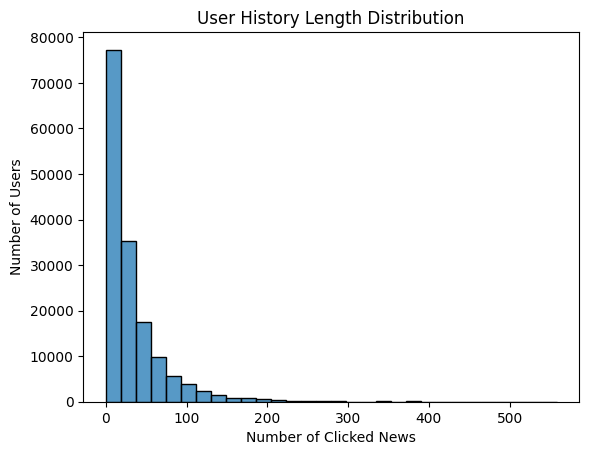

In [7]:
print("Unique users:", behaviors['UserID'].nunique())

# Impression count per user
user_impression_count = behaviors['UserID'].value_counts()

# History length
behaviors['HistoryLength'] = behaviors['History'].apply(lambda x: 0 if pd.isna(x) else len(x.split()))

# Plot
sns.histplot(behaviors['HistoryLength'], bins=30)
plt.title("User History Length Distribution")
plt.xlabel("Number of Clicked News")
plt.ylabel("Number of Users")
plt.show()

3. Time-Based Analysis
Number of impressions over time (daily/hourly)

Click trends over time

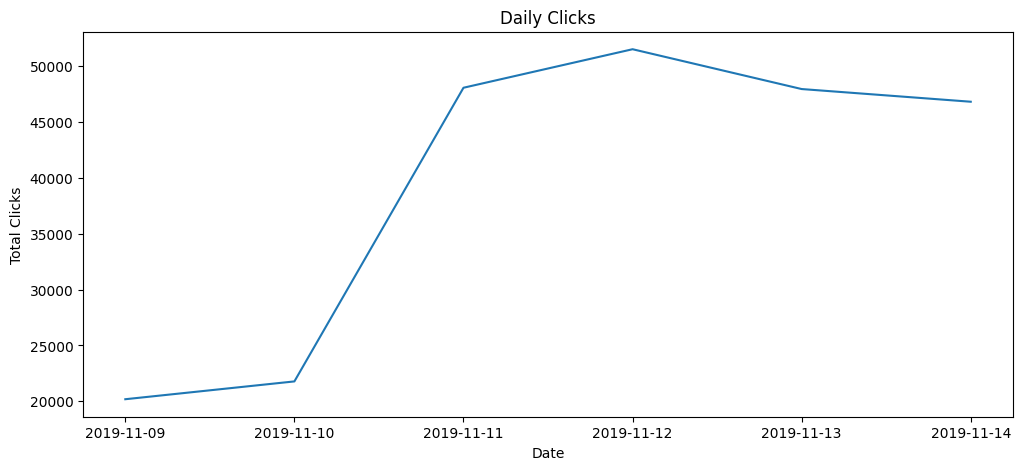

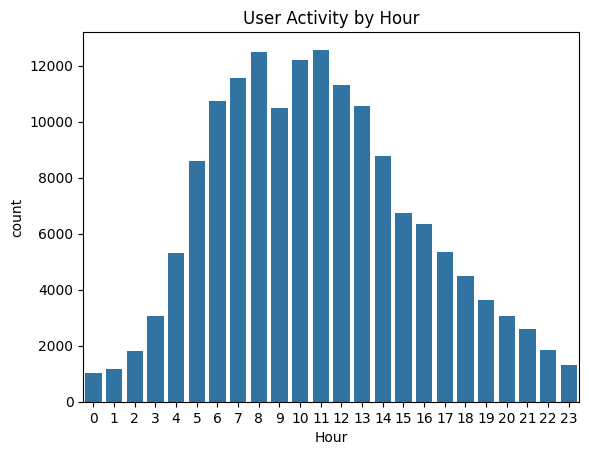

In [8]:
# Daily impressions
daily_clicks = behaviors.groupby(behaviors['Time'].dt.date)['Clicks'].sum()

daily_clicks.plot(figsize=(12, 5), title="Daily Clicks")
plt.xlabel("Date")
plt.ylabel("Total Clicks")
plt.show()

# Hourly activity
behaviors['Hour'] = behaviors['Time'].dt.hour
sns.countplot(data=behaviors, x='Hour')
plt.title("User Activity by Hour")
plt.show()

4. Click-Through Rate (CTR)
Calculate CTR per impression

Distribution of CTR

Average CTR

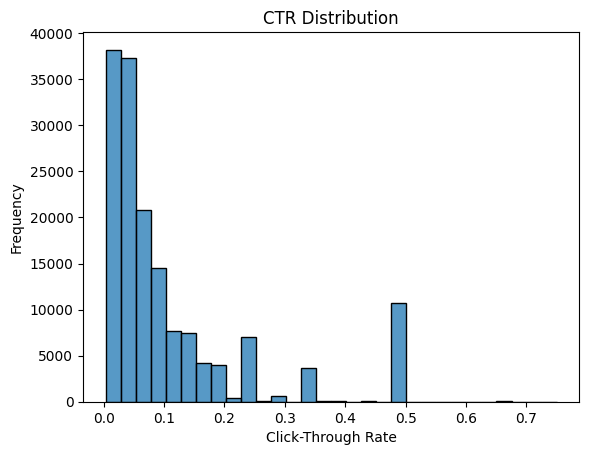

Average CTR: 0.10854419797471164


In [9]:
behaviors['CTR'] = behaviors['Clicks'] / behaviors['TotalShown']

# Plot CTR distribution
sns.histplot(behaviors['CTR'], bins=30)
plt.title("CTR Distribution")
plt.xlabel("Click-Through Rate")
plt.ylabel("Frequency")
plt.show()

# Average CTR
print("Average CTR:", behaviors['CTR'].mean())



 5. Popular News in Impressions
    
Count most frequently shown and clicked news articles

In [10]:
from collections import Counter

# Extract impressions and clicks
impression_lists = behaviors['Impressions'].apply(lambda x: x.split())
clicked_news = []
shown_news = []

for imp in impression_lists:
    for entry in imp:
        nid, click = entry.split('-')
        shown_news.append(nid)
        if click == '1':
            clicked_news.append(nid)

# Frequency
most_shown = Counter(shown_news).most_common(10)
most_clicked = Counter(clicked_news).most_common(10)

print("Most Shown News:", most_shown)
print("Most Clicked News:", most_clicked)

Most Shown News: [('N47061', 23037), ('N51048', 19242), ('N26262', 19106), ('N50872', 18702), ('N55689', 18315), ('N38779', 18101), ('N62360', 16869), ('N13907', 16267), ('N49180', 16022), ('N41020', 15551)]
Most Clicked News: [('N55689', 4316), ('N35729', 3346), ('N33619', 3246), ('N53585', 2835), ('N63970', 2578), ('N49685', 2294), ('N49279', 2270), ('N287', 2128), ('N23446', 1930), ('N51048', 1875)]


6. User Segmentation
   
Identify new users (no history), casual users (short history), and frequent users (long history)

Analyze average CTR per segment


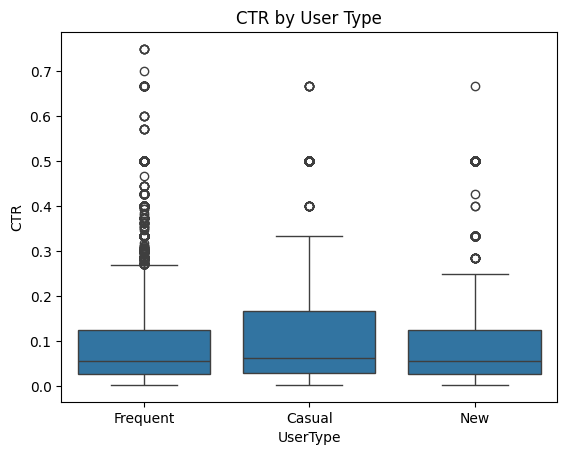

In [11]:
def user_type(length):
    if length == 0:
        return 'New'
    elif length < 5:
        return 'Casual'
    else:
        return 'Frequent'

behaviors['UserType'] = behaviors['HistoryLength'].apply(user_type)
sns.boxplot(data=behaviors, x='UserType', y='CTR')
plt.title("CTR by User Type")
plt.show()

C:\Users\rafi_\AppData\Local\Temp\ipykernel_23176\512670621.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=user_type_counts, x='UserType', y='Count', palette='pastel')


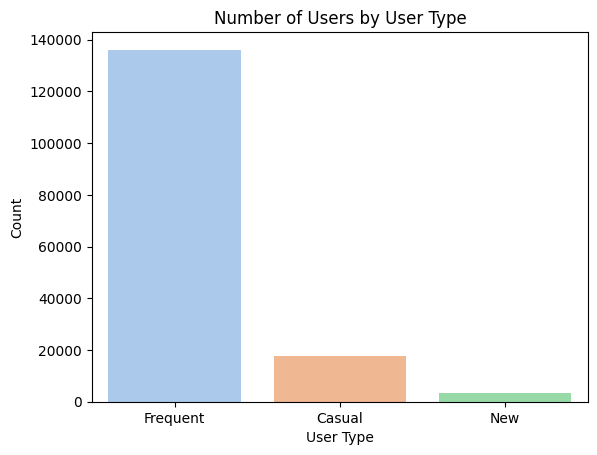

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Count users in each segment
user_type_counts = behaviors['UserType'].value_counts().reset_index()
user_type_counts.columns = ['UserType', 'Count']

# Bar chart
sns.barplot(data=user_type_counts, x='UserType', y='Count', palette='pastel')
plt.title("Number of Users by User Type")
plt.xlabel("User Type")
plt.ylabel("Count")
plt.show()

7. Top Impressions per User
   
Average number of impressions per user

Distribution of impressions length

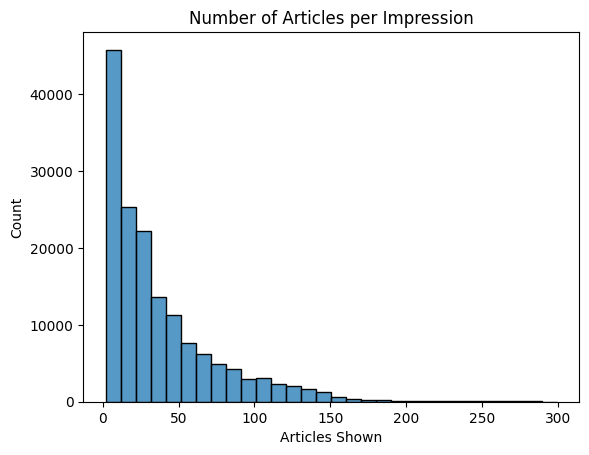

In [13]:
behaviors['ImpressionCount'] = behaviors['Impressions'].apply(lambda x: len(x.split()))
sns.histplot(behaviors['ImpressionCount'], bins=30)
plt.title("Number of Articles per Impression")
plt.xlabel("Articles Shown")
plt.show()

further advancing above analysis

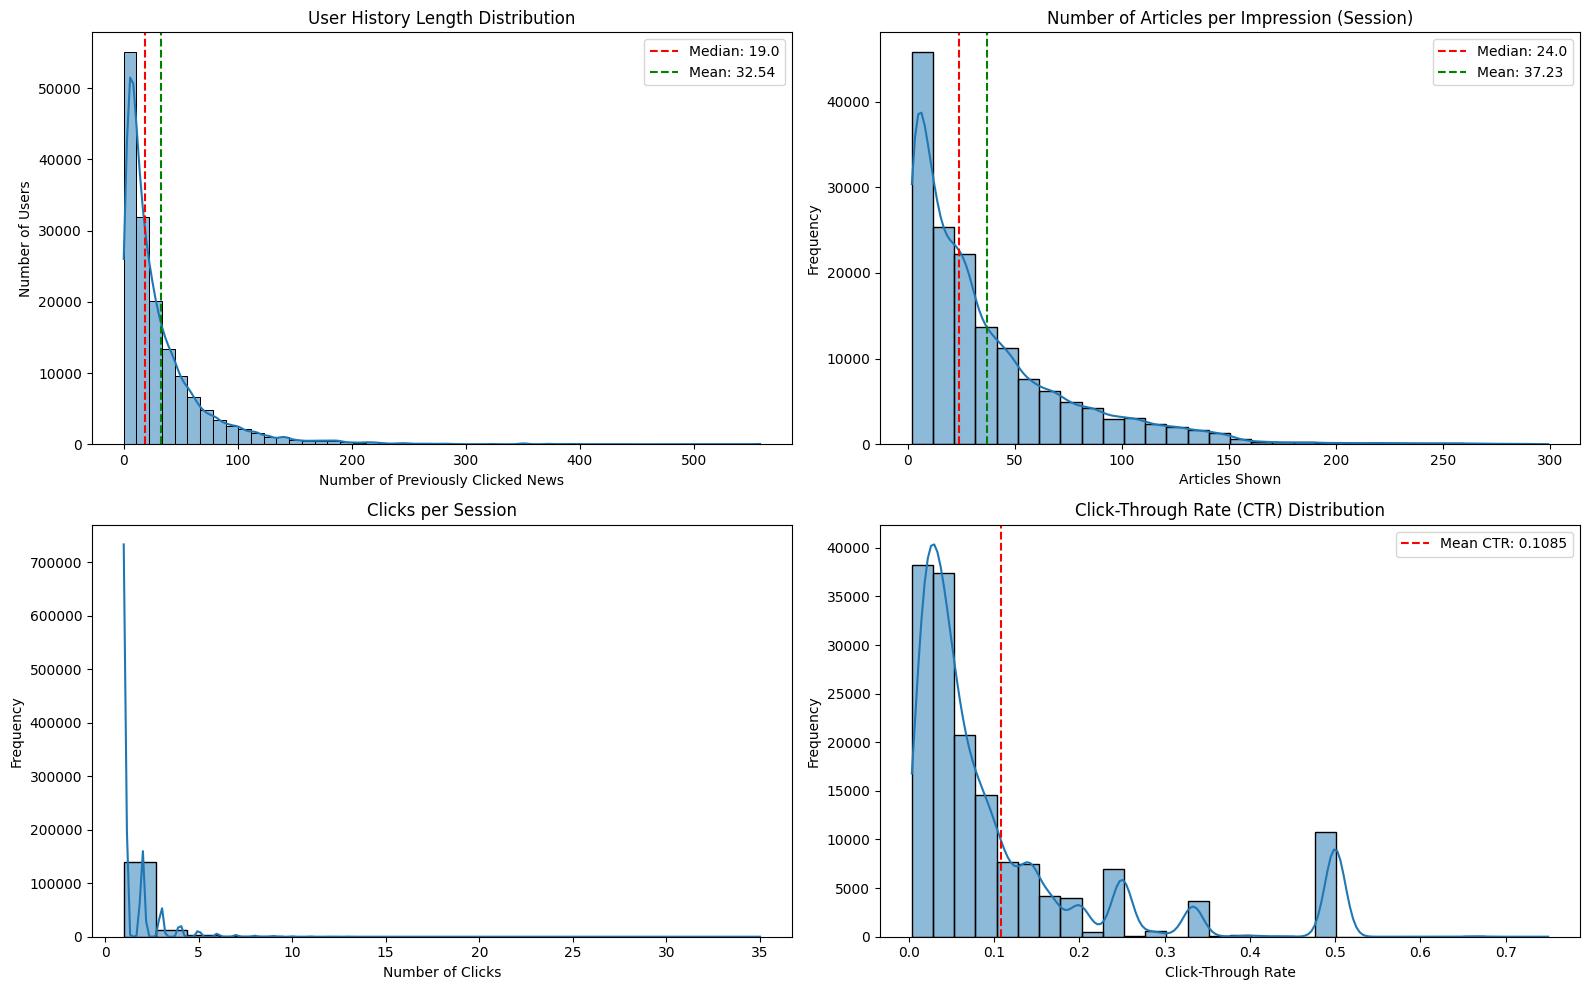

In [14]:
plt.figure(figsize=(16, 10))

# Plot user history length distribution with detailed bins
plt.subplot(2, 2, 1)
sns.histplot(behaviors['HistoryLength'], bins=50, kde=True)
plt.title("User History Length Distribution")
plt.xlabel("Number of Previously Clicked News")
plt.ylabel("Number of Users")
plt.axvline(behaviors['HistoryLength'].median(), color='red', linestyle='--', 
            label=f'Median: {behaviors["HistoryLength"].median()}')
plt.axvline(behaviors['HistoryLength'].mean(), color='green', linestyle='--', 
            label=f'Mean: {behaviors["HistoryLength"].mean():.2f}')
plt.legend()

# Plot impressions per user session
plt.subplot(2, 2, 2)
sns.histplot(behaviors['ImpressionCount'], bins=30, kde=True)
plt.title("Number of Articles per Impression (Session)")
plt.xlabel("Articles Shown")
plt.ylabel("Frequency")
plt.axvline(behaviors['ImpressionCount'].median(), color='red', linestyle='--', 
            label=f'Median: {behaviors["ImpressionCount"].median()}')
plt.axvline(behaviors['ImpressionCount'].mean(), color='green', linestyle='--', 
            label=f'Mean: {behaviors["ImpressionCount"].mean():.2f}')
plt.legend()

# Plot clicks per session
plt.subplot(2, 2, 3)
sns.histplot(behaviors['Clicks'], bins=20, kde=True)
plt.title("Clicks per Session")
plt.xlabel("Number of Clicks")
plt.ylabel("Frequency")

# Plot CTR distribution
plt.subplot(2, 2, 4)
sns.histplot(behaviors['CTR'], bins=30, kde=True)
plt.title("Click-Through Rate (CTR) Distribution")
plt.xlabel("Click-Through Rate")
plt.ylabel("Frequency")
plt.axvline(behaviors['CTR'].mean(), color='red', linestyle='--', 
            label=f'Mean CTR: {behaviors["CTR"].mean():.4f}')
plt.legend()

plt.tight_layout()
plt.show()


 Temporal Patterns Analysis

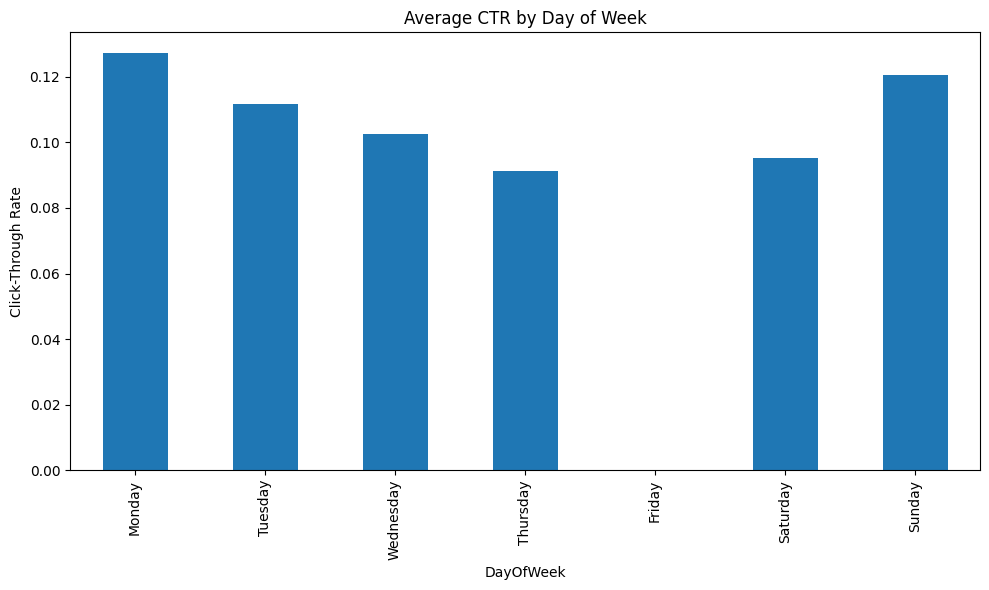

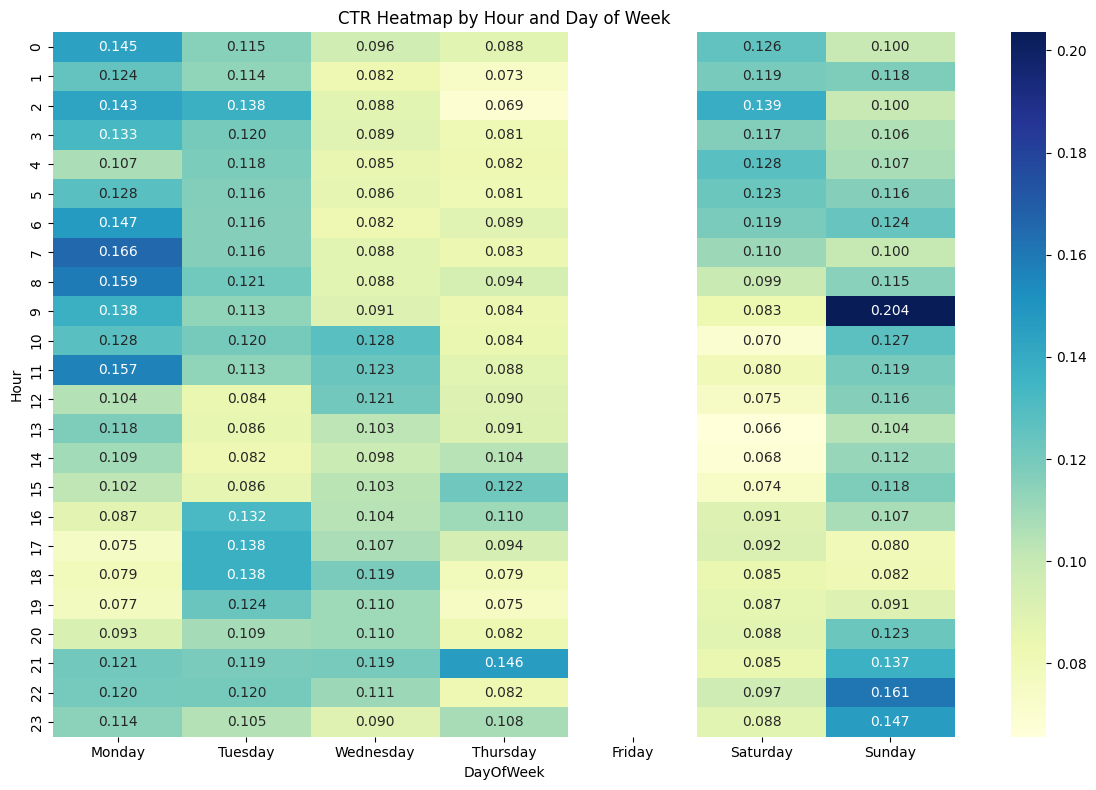

In [15]:
# Time-based analysis
behaviors['DayOfWeek'] = behaviors['Time'].dt.day_name()
behaviors['WeekOfYear'] = behaviors['Time'].dt.isocalendar().week
behaviors['DayOfMonth'] = behaviors['Time'].dt.day

# CTR by day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_ctr = behaviors.groupby('DayOfWeek')['CTR'].mean().reindex(day_order)
dow_ctr.plot(kind='bar', figsize=(10, 6))
plt.title('Average CTR by Day of Week')
plt.ylabel('Click-Through Rate')
plt.tight_layout()
plt.show()

# Heatmap of hour by day of week
hour_day_activity = behaviors.pivot_table(
    index='Hour', 
    columns='DayOfWeek', 
    values='CTR', 
    aggfunc='mean'
).reindex(columns=day_order)

plt.figure(figsize=(12, 8))
sns.heatmap(hour_day_activity, cmap='YlGnBu', annot=True, fmt=".3f")
plt.title('CTR Heatmap by Hour and Day of Week')
plt.tight_layout()
plt.show()

In [16]:
# Extract time components
behaviors['Date'] = behaviors['Time'].dt.date
behaviors['Hour'] = behaviors['Time'].dt.hour
behaviors['DayName'] = behaviors['Time'].dt.day_name()

C:\Users\rafi_\AppData\Local\Temp\ipykernel_23176\10549526.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ctr_by_type.index, y=ctr_by_type.values, palette='rocket')


([0, 1, 2], [Text(0, 0, 'Casual'), Text(1, 0, 'Frequent'), Text(2, 0, 'New')])

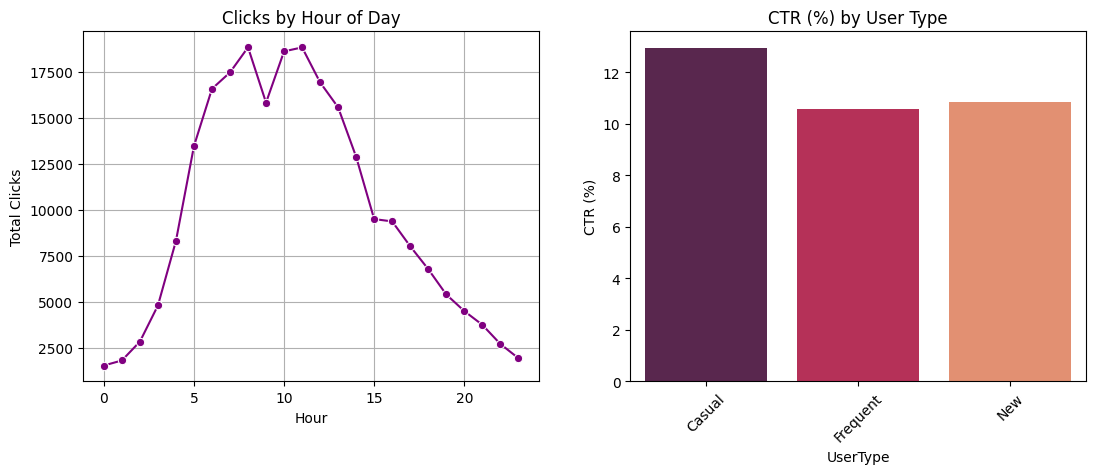

In [17]:
plt.figure(figsize=(20, 10))  # width=15 inches, height=8 inches


#Time distribution
plt.subplot(2, 3, 4)
hour_activity = behaviors.groupby('Hour')['Clicks'].sum()
sns.lineplot(x=hour_activity.index, y=hour_activity.values, marker='o', color='purple')
plt.title('Clicks by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Total Clicks')
plt.grid(True)

# 5. CTR by user type
plt.subplot(2, 3, 5)
ctr_by_type = behaviors.groupby('UserType')['CTR'].mean() * 100
sns.barplot(x=ctr_by_type.index, y=ctr_by_type.values, palette='rocket')
plt.title('CTR (%) by User Type')
plt.ylabel('CTR (%)')
plt.xticks(rotation=45)

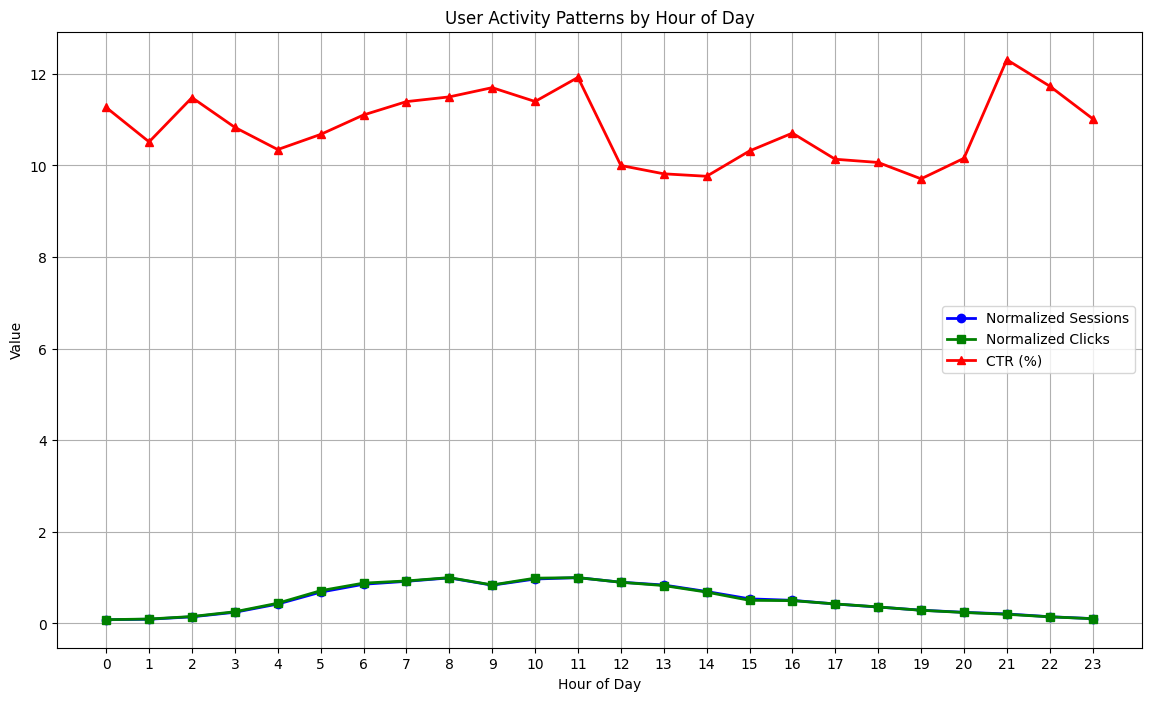

In [18]:
# Time of day analysis - Enhanced version
hourly_metrics = behaviors.groupby('Hour').agg({
    'ImpressionID': 'count',
    'Clicks': 'sum', 
    'TotalShown': 'sum',
    'CTR': 'mean'
})

hourly_metrics['Normalized_Sessions'] = hourly_metrics['ImpressionID'] / hourly_metrics['ImpressionID'].max()
hourly_metrics['Normalized_Clicks'] = hourly_metrics['Clicks'] / hourly_metrics['Clicks'].max()

# Plot time of day metrics
plt.figure(figsize=(14, 8))
plt.plot(hourly_metrics.index, hourly_metrics['Normalized_Sessions'], 'b-', marker='o', 
         linewidth=2, label='Normalized Sessions')
plt.plot(hourly_metrics.index, hourly_metrics['Normalized_Clicks'], 'g-', marker='s', 
         linewidth=2, label='Normalized Clicks')
plt.plot(hourly_metrics.index, hourly_metrics['CTR'] * 100, 'r-', marker='^', 
         linewidth=2, label='CTR (%)')

plt.title('User Activity Patterns by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Value')
plt.xticks(range(24))
plt.legend()
plt.grid(True)
plt.show()



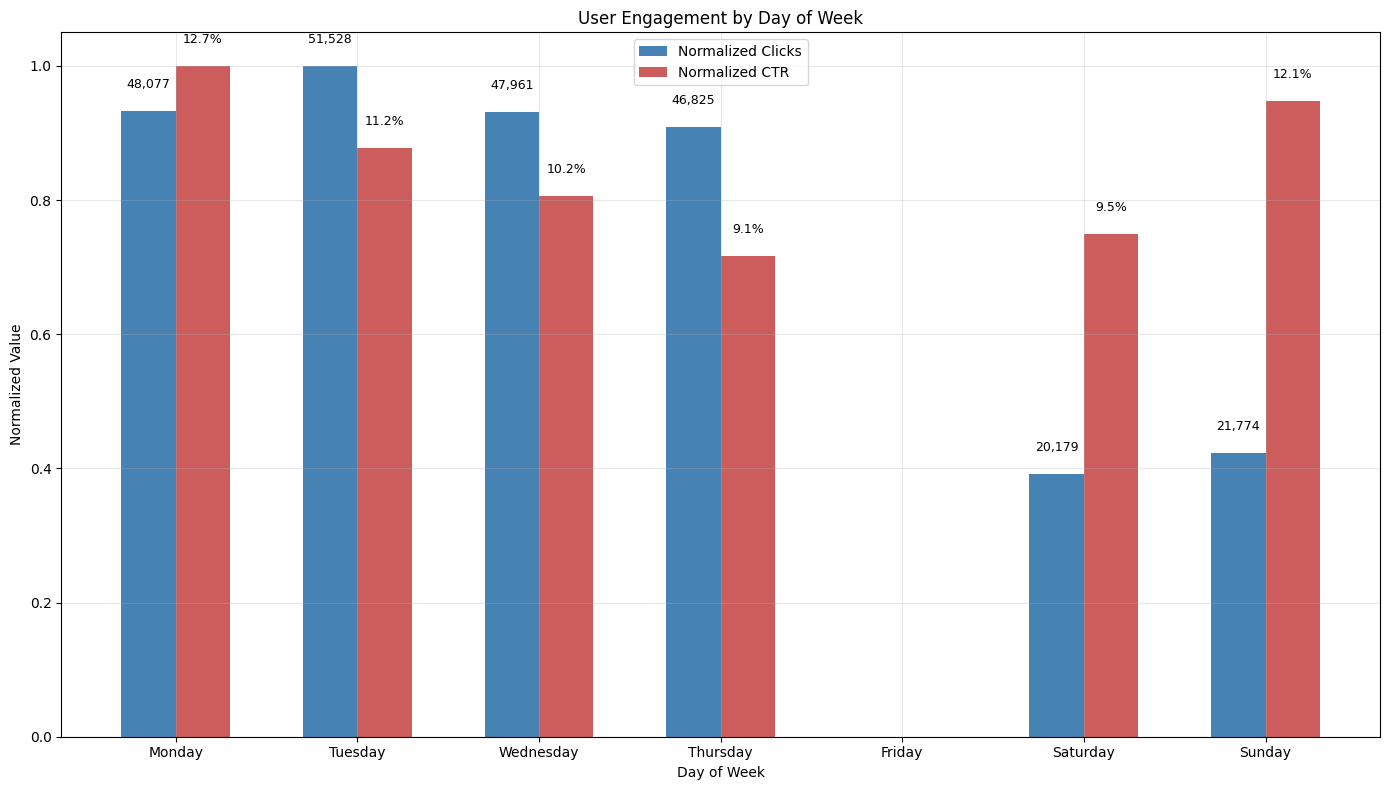

In [19]:
# Day of week analysis
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_metrics = behaviors.groupby('DayName').agg({
    'ImpressionID': 'count',
    'Clicks': 'sum',
    'TotalShown': 'sum',
    'UserID': 'nunique',
    'CTR': 'mean'
}).reindex(day_order)

day_metrics['ClicksPerUser'] = day_metrics['Clicks'] / day_metrics['UserID']

# Create a multi-bar chart for day of week
plt.figure(figsize=(14, 8))
x = np.arange(len(day_order))
width = 0.3

# Normalized clicks
plt.bar(x - width/2, day_metrics['Clicks'] / day_metrics['Clicks'].max(), 
        width, label='Normalized Clicks', color='steelblue')

# CTR
plt.bar(x + width/2, day_metrics['CTR'] * 100 / (day_metrics['CTR'] * 100).max(), 
        width, label='Normalized CTR', color='indianred')

plt.title('User Engagement by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Normalized Value')
plt.xticks(x, day_order)
plt.legend()
plt.grid(True, alpha=0.3)

# Annotate with actual values
for i, day in enumerate(day_order):
    plt.annotate(f"{day_metrics.loc[day, 'Clicks']:,.0f}", 
                 xy=(i - width/2, day_metrics.loc[day, 'Clicks'] / day_metrics['Clicks'].max() + 0.03),
                 ha='center', va='bottom', fontsize=9, rotation=0)
    
    plt.annotate(f"{day_metrics.loc[day, 'CTR']*100:.1f}%", 
                 xy=(i + width/2, day_metrics.loc[day, 'CTR'] * 100 / (day_metrics['CTR'] * 100).max() + 0.03),
                 ha='center', va='bottom', fontsize=9, rotation=0)

plt.tight_layout()
plt.show()


User Session Analysis

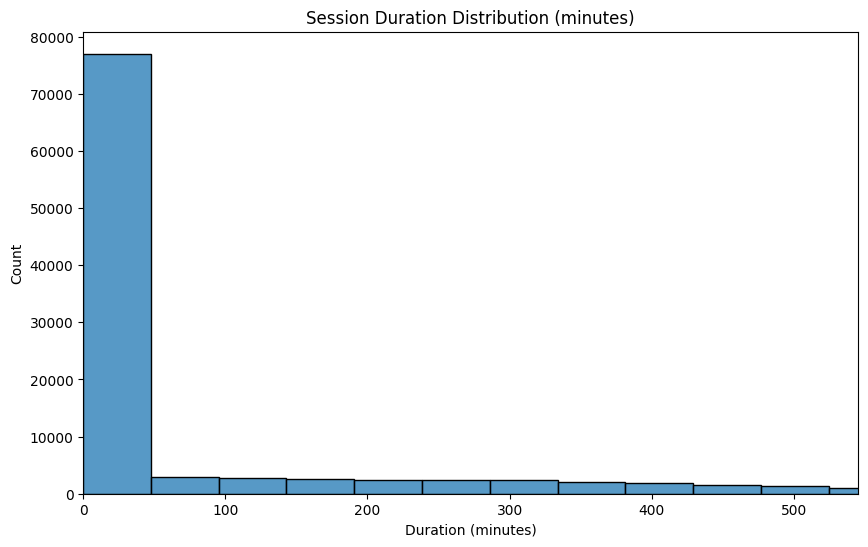

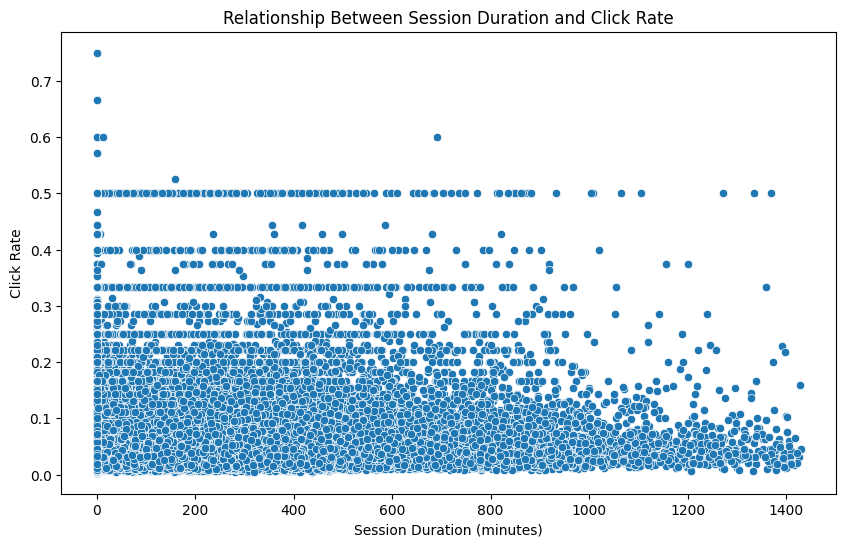

In [20]:
# Create session ID by combining user and date
behaviors['SessionDate'] = behaviors['Time'].dt.date
behaviors['SessionID'] = behaviors['UserID'] + '-' + behaviors['SessionDate'].astype(str)

# Calculate session-level metrics
session_metrics = behaviors.groupby('SessionID').agg({
    'ImpressionID': 'count',
    'Clicks': 'sum',
    'TotalShown': 'sum',
    'Time': ['min', 'max']
}).reset_index()

# Calculate session duration
session_metrics['SessionDuration'] = (
    session_metrics[('Time', 'max')] - session_metrics[('Time', 'min')]
).dt.total_seconds() / 60  # Convert to minutes

# Session duration analysis
plt.figure(figsize=(10, 6))
sns.histplot(session_metrics['SessionDuration'], bins=30)
plt.title('Session Duration Distribution (minutes)')
plt.xlabel('Duration (minutes)')
plt.xlim(0, session_metrics['SessionDuration'].quantile(0.95))  # Remove outliers
plt.show()

# Correlation between session duration and engagement
plt.figure(figsize=(10, 6))
session_metrics['ClickRate'] = session_metrics[('Clicks', 'sum')] / session_metrics[('TotalShown', 'sum')]
sns.scatterplot(x='SessionDuration', y='ClickRate', data=session_metrics)
plt.title('Relationship Between Session Duration and Click Rate')
plt.xlabel('Session Duration (minutes)')
plt.ylabel('Click Rate')
plt.show()

 User Retention and Recency Analysis

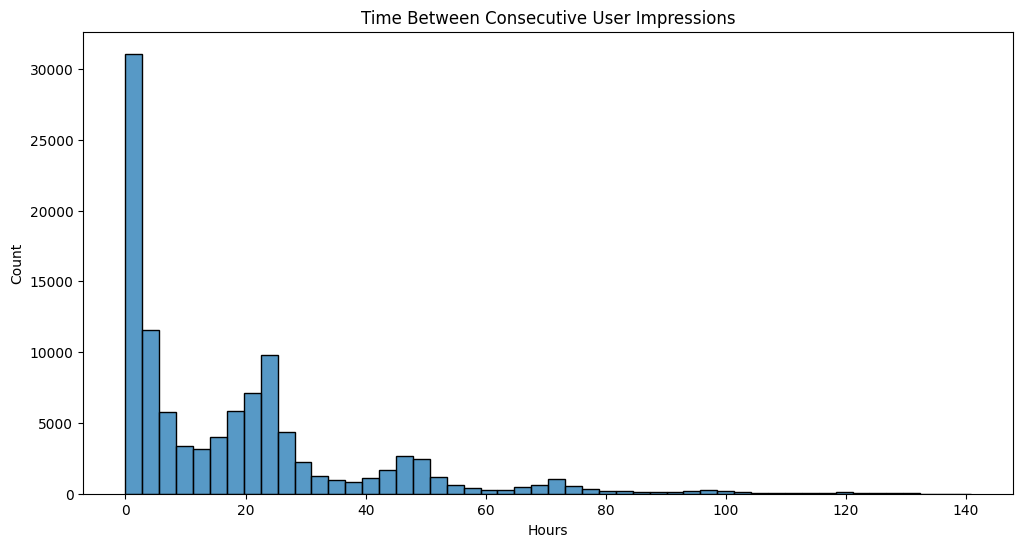

C:\Users\rafi_\AppData\Local\Temp\ipykernel_23176\3487085044.py:24: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=behaviors_sorted.dropna(subset=['RollingCTR']), x='TimeSinceLast', y='RollingCTR', ci=None)


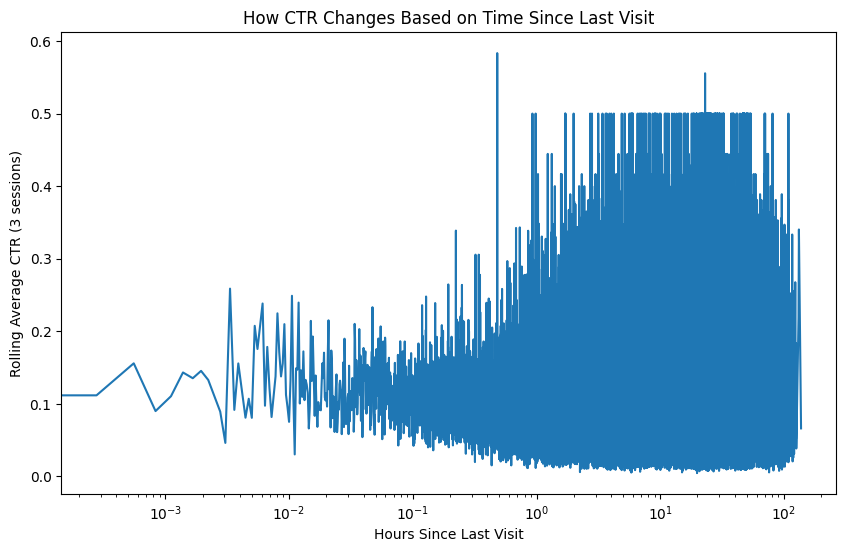

In [21]:
# Sort data by user and time
behaviors_sorted = behaviors.sort_values(['UserID', 'Time'])

# Calculate time between consecutive impressions for each user
behaviors_sorted['PrevTime'] = behaviors_sorted.groupby('UserID')['Time'].shift(1)
behaviors_sorted['TimeSinceLast'] = (behaviors_sorted['Time'] - behaviors_sorted['PrevTime']).dt.total_seconds() / 3600  # Hours

# Filter out first impression for each user (NaN time difference)
time_diffs = behaviors_sorted.dropna(subset=['TimeSinceLast'])

# Distribution of time between sessions
plt.figure(figsize=(12, 6))
sns.histplot(time_diffs['TimeSinceLast'].clip(upper=168), bins=50)  # Clip at one week
plt.title('Time Between Consecutive User Impressions')
plt.xlabel('Hours')
plt.show()

# Calculate rolling engagement metrics
behaviors_sorted['RollingClicks'] = behaviors_sorted.groupby('UserID')['Clicks'].rolling(window=3).sum().reset_index(level=0, drop=True)
behaviors_sorted['RollingCTR'] = behaviors_sorted.groupby('UserID')['CTR'].rolling(window=3).mean().reset_index(level=0, drop=True)

# Plot how engagement changes over consecutive sessions
plt.figure(figsize=(10, 6))
sns.lineplot(data=behaviors_sorted.dropna(subset=['RollingCTR']), x='TimeSinceLast', y='RollingCTR', ci=None)
plt.title('How CTR Changes Based on Time Since Last Visit')
plt.xlabel('Hours Since Last Visit')
plt.ylabel('Rolling Average CTR (3 sessions)')
plt.xscale('log')
plt.show()

 Content Interaction Patterns (integrating news.tsv)

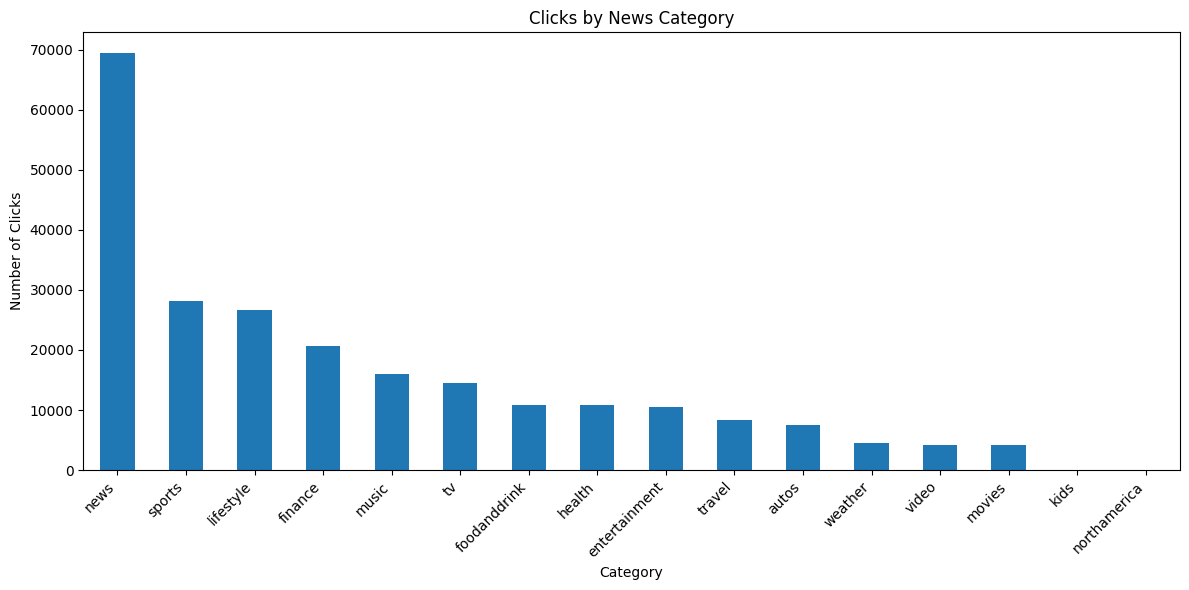

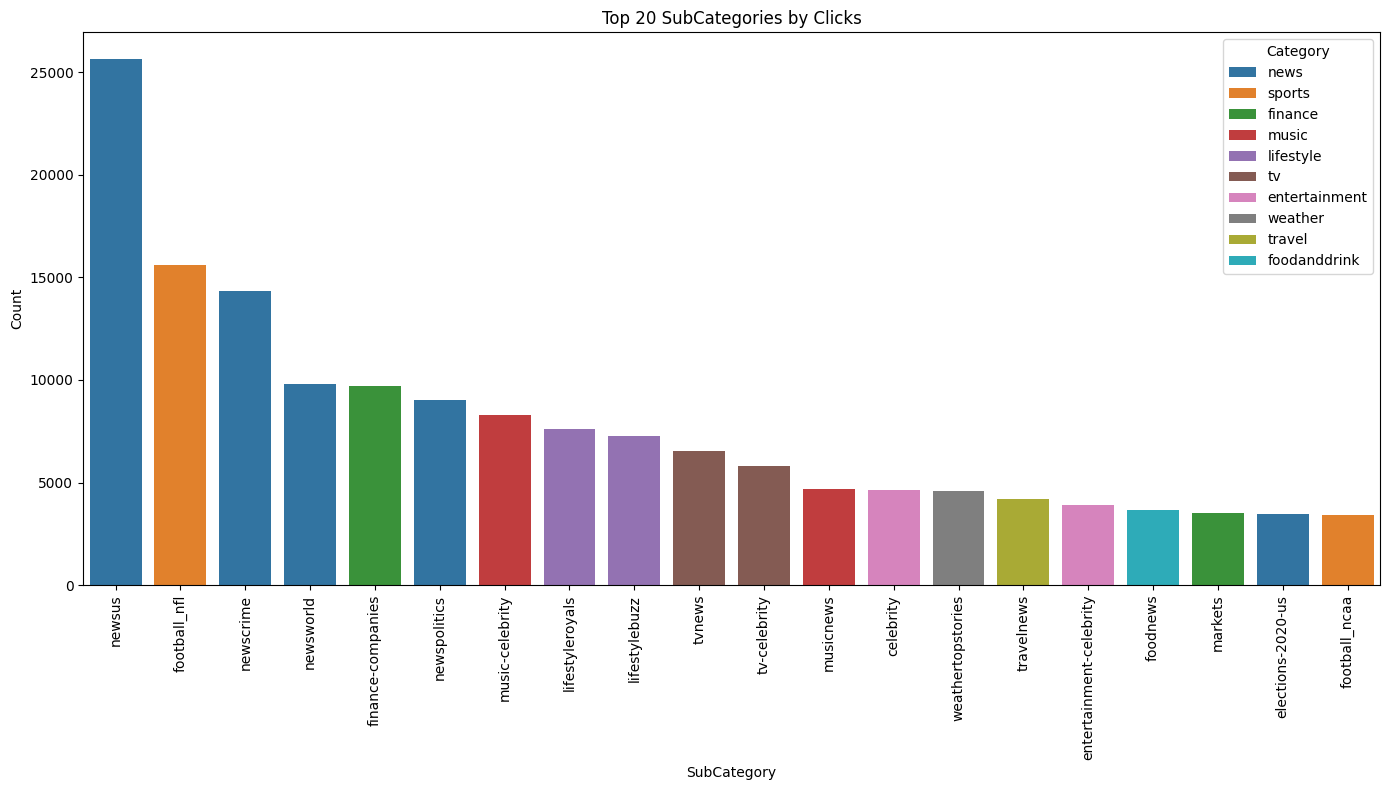

In [22]:
# Extract all clicked news IDs
all_clicks = []
for imp in behaviors['Impressions']:
    news_items = imp.split()
    for item in news_items:
        nid, click = item.split('-')
        if click == '1':
            all_clicks.append(nid)

clicked_news = pd.DataFrame(all_clicks, columns=['NewsID'])
clicked_news['Count'] = 1
clicked_news = clicked_news.groupby('NewsID').sum().reset_index()

# Merge with news categories
news_clicks = clicked_news.merge(news[['NewsID', 'Category', 'SubCategory']], on='NewsID', how='left')

# Category popularity
category_clicks = news_clicks.groupby('Category')['Count'].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
category_clicks.plot(kind='bar')
plt.title('Clicks by News Category')
plt.xlabel('Category')
plt.ylabel('Number of Clicks')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Subcategory analysis
subcategory_clicks = news_clicks.groupby(['Category', 'SubCategory'])['Count'].sum().reset_index()
subcategory_clicks = subcategory_clicks.sort_values('Count', ascending=False)

plt.figure(figsize=(14, 8))
sns.barplot(data=subcategory_clicks.head(20), x='SubCategory', y='Count', hue='Category')
plt.title('Top 20 SubCategories by Clicks')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Advanced User Segmentation with Clustering

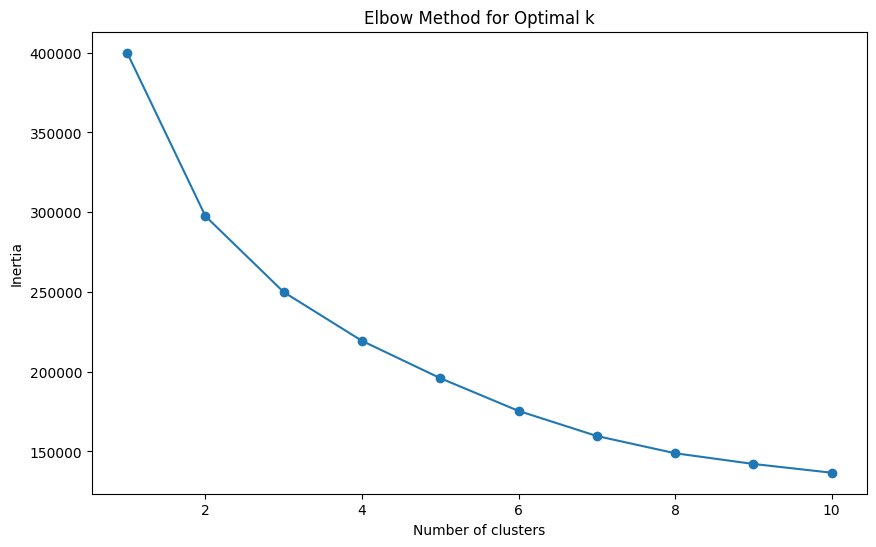

Cluster Profiles:
   Cluster  ImpressionID       CTR  HistoryLength       Hour  \
0        0      2.877712  0.047034      19.595622  10.581321   
1        1      2.485845  0.082143      13.178054  10.954571   
2        2     10.591889  0.090268      70.150154  10.732071   
3        3      2.104568  0.330895      10.438542  10.635496   

   ClicksPerImpression  ImpressionsPerSession  UserID  
0             2.120117              79.733964   10369  
1             1.204099              27.857490   27941  
2             1.975835              45.461444    3896  
3             1.123351               7.187757    7794  


<Figure size 1200x1000 with 0 Axes>

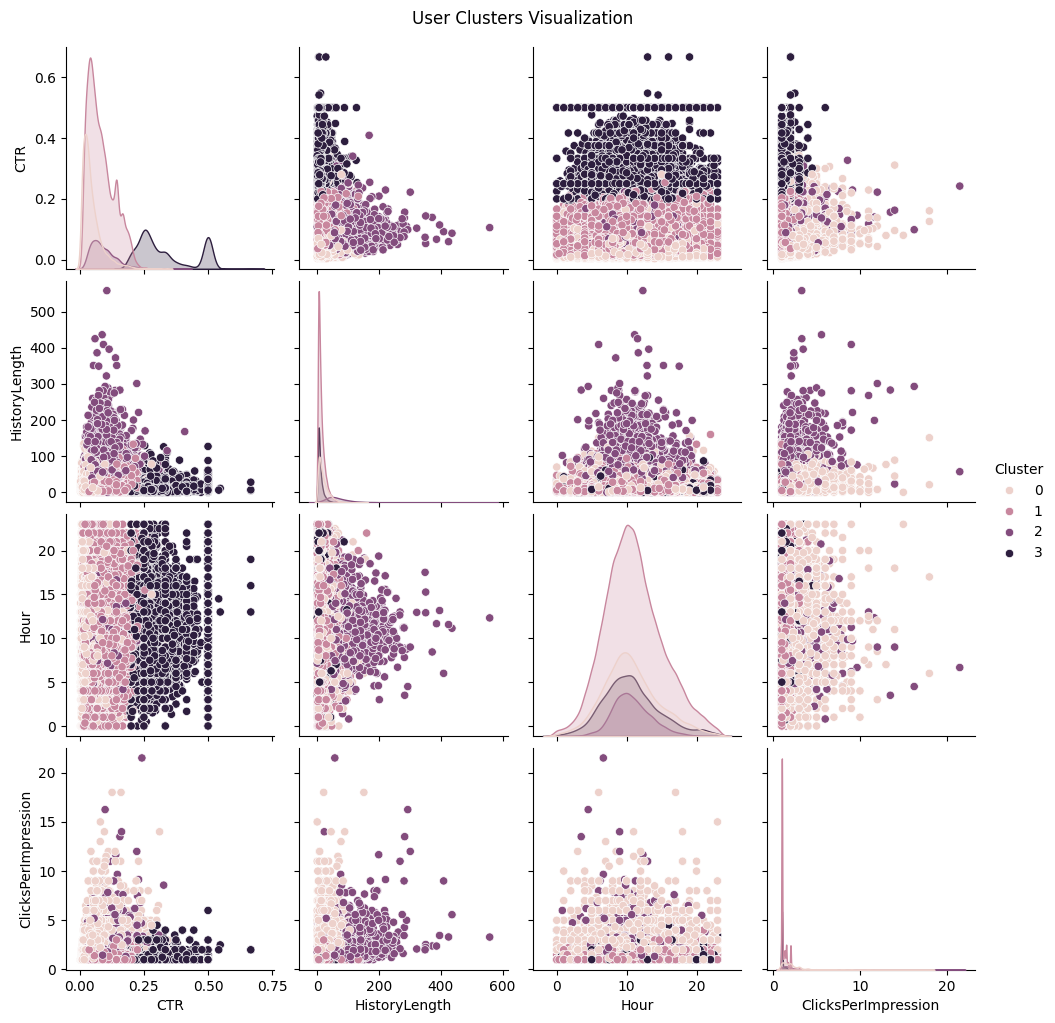

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Create user-level features for clustering
user_features = behaviors.groupby('UserID').agg({
    'ImpressionID': 'count',
    'Clicks': 'sum',
    'TotalShown': 'sum',
    'CTR': 'mean',
    'HistoryLength': 'max',
    'Hour': 'mean'  # Average hour of day
}).reset_index()

# Add more features
user_features['ClicksPerImpression'] = user_features['Clicks'] / user_features['ImpressionID']
user_features['ImpressionsPerSession'] = user_features['TotalShown'] / user_features['ImpressionID']

# Scale features for clustering
features_for_clustering = user_features.drop('UserID', axis=1)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_for_clustering)

# Determine optimal number of clusters using elbow method
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

# Apply K-means with optimal k (let's assume k=4)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
user_features['Cluster'] = kmeans.fit_predict(scaled_features)

# Analyze clusters
cluster_profiles = user_features.groupby('Cluster').agg({
    'ImpressionID': 'mean',
    'CTR': 'mean',
    'HistoryLength': 'mean',
    'Hour': 'mean',
    'ClicksPerImpression': 'mean',
    'ImpressionsPerSession': 'mean',
    'UserID': 'count'  # Size of cluster
}).reset_index()

print("Cluster Profiles:")
print(cluster_profiles)

# Visualize clusters
plt.figure(figsize=(12, 10))
sns.pairplot(user_features, hue='Cluster', vars=['CTR', 'HistoryLength', 'Hour', 'ClicksPerImpression'])
plt.suptitle('User Clusters Visualization', y=1.02)
plt.show()

User Segment Analysis:
          UserID HistoryLength                CTR                Clicks  \
         nunique          mean median  max   mean median    max     sum   
UserType                                                                  
Casual      8777         2.903    3.0    4  0.129  0.062  0.667   22302   
Frequent   40331        37.148   23.0  558  0.106  0.056  0.750  209228   
New          892         0.000    0.0    0  0.108  0.057  0.667    4814   

                       TotalShown         ImpressionCount         
           mean median        sum    mean            mean median  
UserType                                                          
Casual    1.267    1.0     562282  31.935          31.935   19.0  
Frequent  1.537    1.0    5160720  37.913          37.913   25.0  
New       1.487    1.0     120442  37.196          37.196   23.0  


C:\Users\rafi_\AppData\Local\Temp\ipykernel_23176\2328187005.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Segment', y='Users', data=segment_metrics, palette='viridis')
C:\Users\rafi_\AppData\Local\Temp\ipykernel_23176\2328187005.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Segment', y='Avg History', data=segment_metrics, palette='plasma')
C:\Users\rafi_\AppData\Local\Temp\ipykernel_23176\2328187005.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Segment', y='Avg CTR', data=segment_metrics, palette='rocket')
C:\U

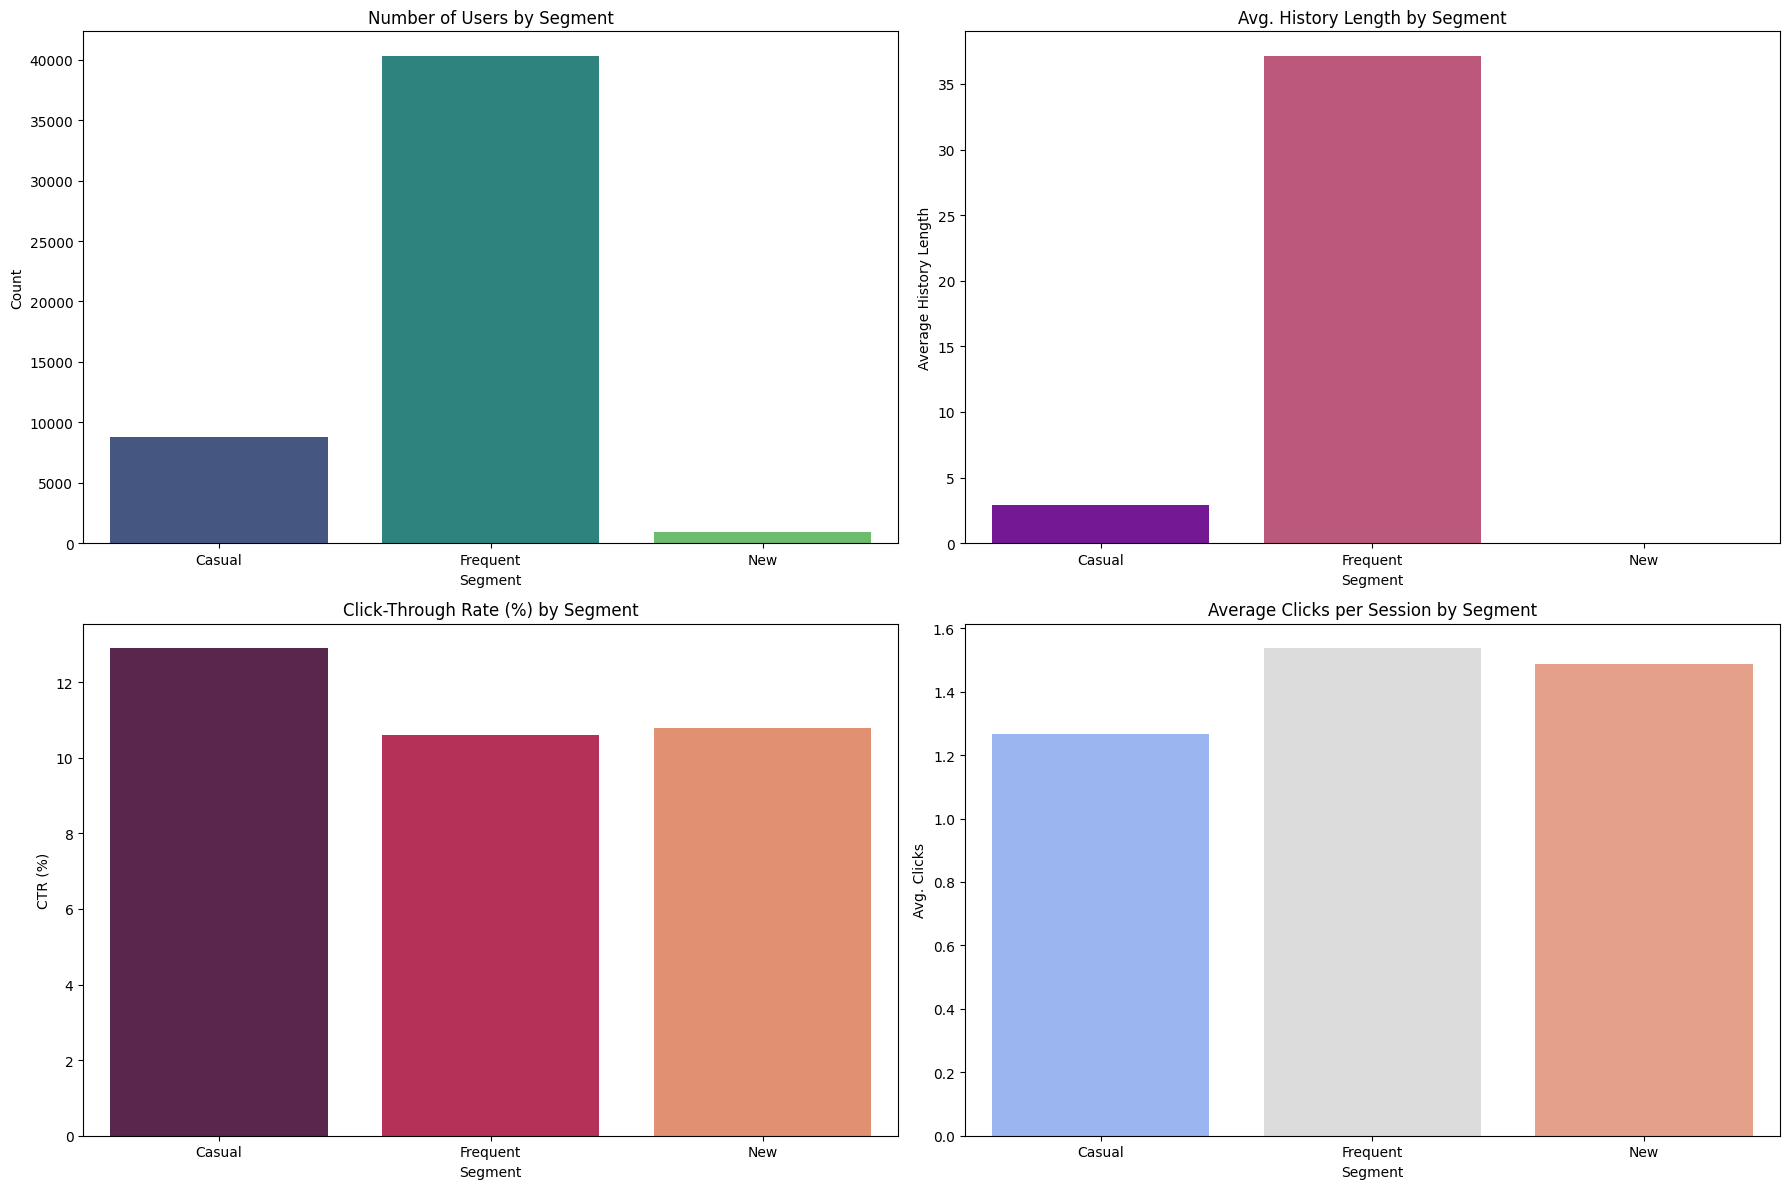

In [24]:
user_segments = behaviors.groupby('UserType').agg({
    'UserID': 'nunique',
    'HistoryLength': ['mean', 'median', 'max'],
    'CTR': ['mean', 'median', 'max'],
    'Clicks': ['sum', 'mean', 'median'],
    'TotalShown': ['sum', 'mean'],
    'ImpressionCount': ['mean', 'median']
}).round(3)

print("User Segment Analysis:")
print(user_segments)

# Prepare segmentation visualization data
segment_metrics = pd.DataFrame({
    'Segment': user_segments.index,
    'Users': user_segments[('UserID', 'nunique')],
    'Avg History': user_segments[('HistoryLength', 'mean')],
    'Avg CTR': user_segments[('CTR', 'mean')] * 100,  # Convert to percentage
    'Avg Clicks per Session': user_segments[('Clicks', 'mean')],
    'Total Clicks': user_segments[('Clicks', 'sum')]
})

# Create visualizations for user segments
plt.figure(figsize=(18, 12))

# User count by segment
plt.subplot(2, 2, 1)
sns.barplot(x='Segment', y='Users', data=segment_metrics, palette='viridis')
plt.title('Number of Users by Segment')
plt.ylabel('Count')

# Average history length by segment
plt.subplot(2, 2, 2)
sns.barplot(x='Segment', y='Avg History', data=segment_metrics, palette='plasma')
plt.title('Avg. History Length by Segment')
plt.ylabel('Average History Length')

# CTR by segment 
plt.subplot(2, 2, 3)
sns.barplot(x='Segment', y='Avg CTR', data=segment_metrics, palette='rocket')
plt.title('Click-Through Rate (%) by Segment')
plt.ylabel('CTR (%)')

# Avg clicks per session by segment
plt.subplot(2, 2, 4)
sns.barplot(x='Segment', y='Avg Clicks per Session', data=segment_metrics, palette='coolwarm')
plt.title('Average Clicks per Session by Segment')
plt.ylabel('Avg. Clicks')

plt.tight_layout()
plt.show()

Content Interest Analysis & User Preferences

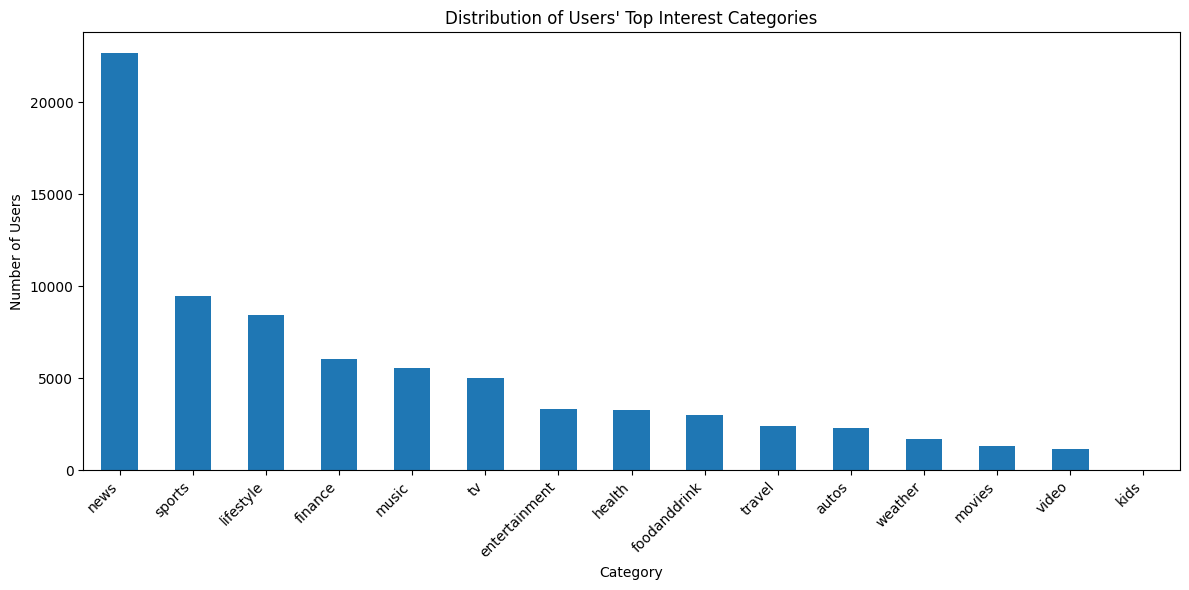

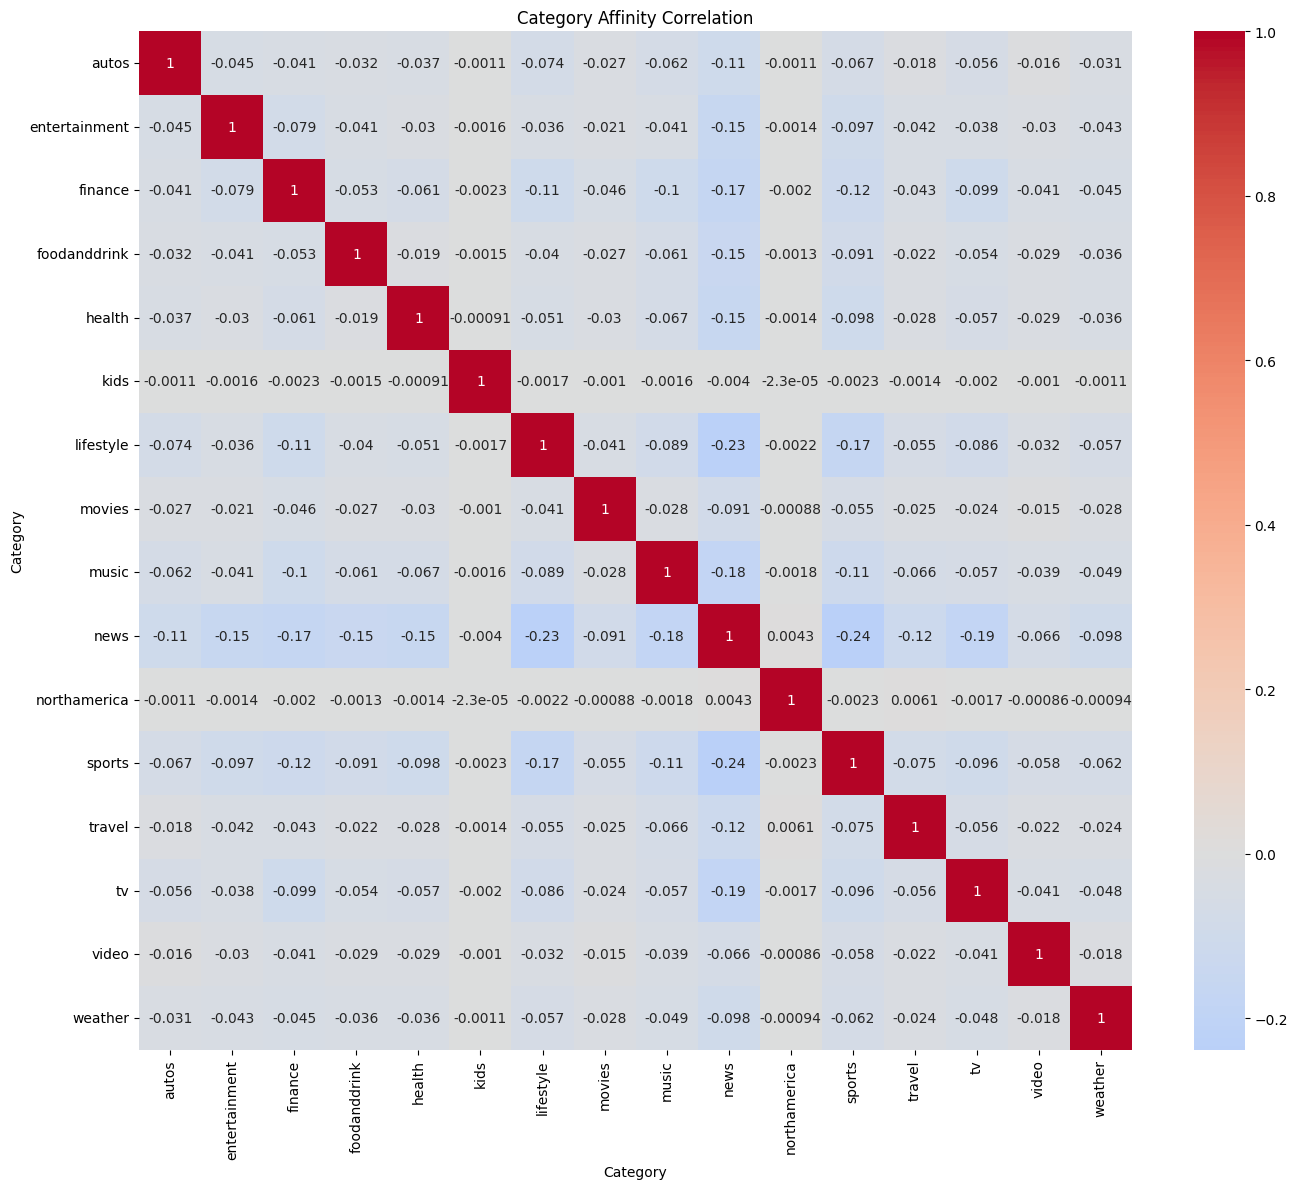

In [25]:
# Extract the categories of news each user has clicked
user_clicks = []

for idx, row in behaviors.iterrows():
    user_id = row['UserID']
    impressions = row['Impressions'].split()
    
    for imp in impressions:
        news_id, clicked = imp.split('-')
        if clicked == '1':
            user_clicks.append({'UserID': user_id, 'NewsID': news_id})

user_click_df = pd.DataFrame(user_clicks)

# Merge with news data to get categories
user_categories = user_click_df.merge(news[['NewsID', 'Category']], left_on='NewsID', right_on='NewsID')

# Count category clicks per user
user_category_counts = user_categories.groupby(['UserID', 'Category']).size().reset_index(name='Count')

# Calculate category preferences as percentages
user_total_clicks = user_category_counts.groupby('UserID')['Count'].sum().reset_index(name='TotalClicks')
user_category_counts = user_category_counts.merge(user_total_clicks, on='UserID')
user_category_counts['Preference'] = user_category_counts['Count'] / user_category_counts['TotalClicks']

# Create user-category matrix
user_category_matrix = user_category_counts.pivot(index='UserID', columns='Category', values='Preference').fillna(0)

# Identify top category for each user
user_category_counts['Rank'] = user_category_counts.groupby('UserID')['Count'].rank(method='dense', ascending=False)
top_categories = user_category_counts[user_category_counts['Rank'] == 1]

# Plot distribution of top categories
plt.figure(figsize=(12, 6))
top_cat_counts = top_categories['Category'].value_counts()
top_cat_counts.plot(kind='bar')
plt.title('Distribution of Users\' Top Interest Categories')
plt.xlabel('Category')
plt.ylabel('Number of Users')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Visualize category affinity with heatmap
plt.figure(figsize=(14, 12))
category_corr = user_category_matrix.corr()
sns.heatmap(category_corr, annot=True, cmap='coolwarm', center=0)
plt.title('Category Affinity Correlation')
plt.tight_layout()
plt.show()

Sequential Pattern Mining

Top article sequences: [(('N47020', 'N47020'), 1274), (('N31801', 'N306'), 1027), (('N31801', 'N11005'), 1007), (('N45794', 'N59704'), 965), (('N29177', 'N1150'), 926), (('N46392', 'N45794'), 853), (('N306', 'N43142'), 757), (('N42620', 'N36530'), 736), (('N46392', 'N59704'), 720), (('N43142', 'N41375'), 713), (('N4020', 'N51706'), 705), (('N31801', 'N54225'), 693), (('N306', 'N26026'), 690), (('N27448', 'N55189'), 688), (('N61864', 'N61864'), 662), (('N36530', 'N42620'), 660), (('N13138', 'N42620'), 657), (('N45794', 'N46392'), 656), (('N43142', 'N33096'), 655), (('N32004', 'N4607'), 630)]


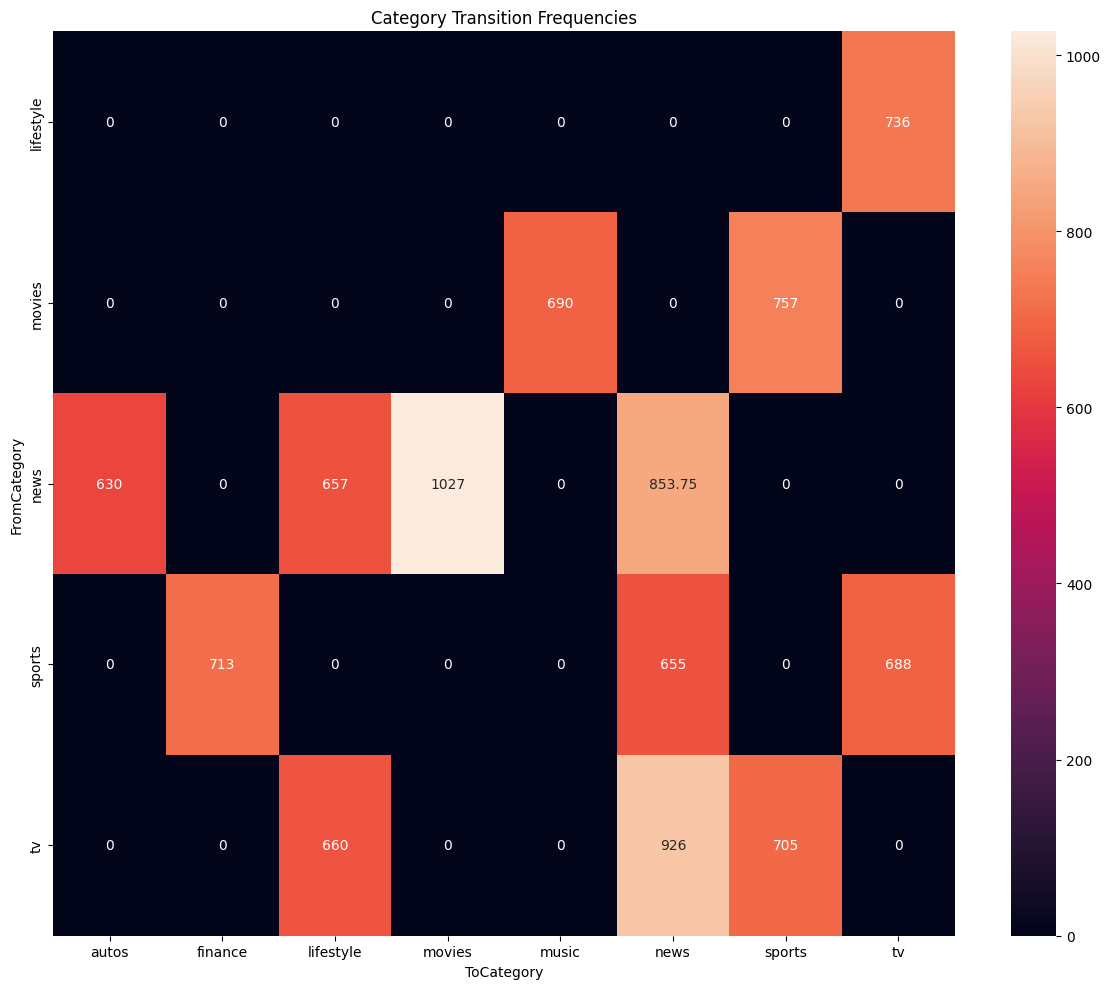

In [26]:
# For users with adequate history, analyze sequence patterns
def get_sequence(history_str):
    if pd.isna(history_str) or history_str == '':
        return []
    return history_str.split()

behaviors['HistorySequence'] = behaviors['History'].apply(get_sequence)

# Filter users with significant history
significant_histories = behaviors[behaviors['HistoryLength'] >= 5]

# Extract common subsequences (this is a simplified approach)
from collections import defaultdict

# Count bigrams (pairs of consecutive articles)
bigrams = defaultdict(int)
for history in significant_histories['HistorySequence']:
    for i in range(len(history) - 1):
        pair = (history[i], history[i+1])
        bigrams[pair] += 1

# Get top transitions
top_bigrams = sorted(bigrams.items(), key=lambda x: x[1], reverse=True)[:20]
print("Top article sequences:", top_bigrams)

# If you can merge with news data:
bigram_categories = []
for (article1, article2), count in top_bigrams:
    cat1 = news[news['NewsID'] == article1]['Category'].values[0] if article1 in news['NewsID'].values else 'Unknown'
    cat2 = news[news['NewsID'] == article2]['Category'].values[0] if article2 in news['NewsID'].values else 'Unknown'
    bigram_categories.append((cat1, cat2, count))

# Visualize category transitions
transitions = pd.DataFrame(bigram_categories, columns=['FromCategory', 'ToCategory', 'Count'])
transition_matrix = transitions.pivot_table(index='FromCategory', columns='ToCategory', values='Count', fill_value=0)

plt.figure(figsize=(12, 10))
sns.heatmap(transition_matrix, annot=True, fmt='g')
plt.title('Category Transition Frequencies')
plt.tight_layout()
plt.show()

News Recommendation System: Key Metrics

C:\Users\rafi_\AppData\Local\Temp\ipykernel_23176\3540403348.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=user_counts.index, y=user_counts.values, palette='viridis')
C:\Users\rafi_\AppData\Local\Temp\ipykernel_23176\3540403348.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette='plasma')


([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'news'),
  Text(1, 0, 'sports'),
  Text(2, 0, 'finance'),
  Text(3, 0, 'foodanddrink'),
  Text(4, 0, 'lifestyle'),
  Text(5, 0, 'travel'),
  Text(6, 0, 'video'),
  Text(7, 0, 'weather')])

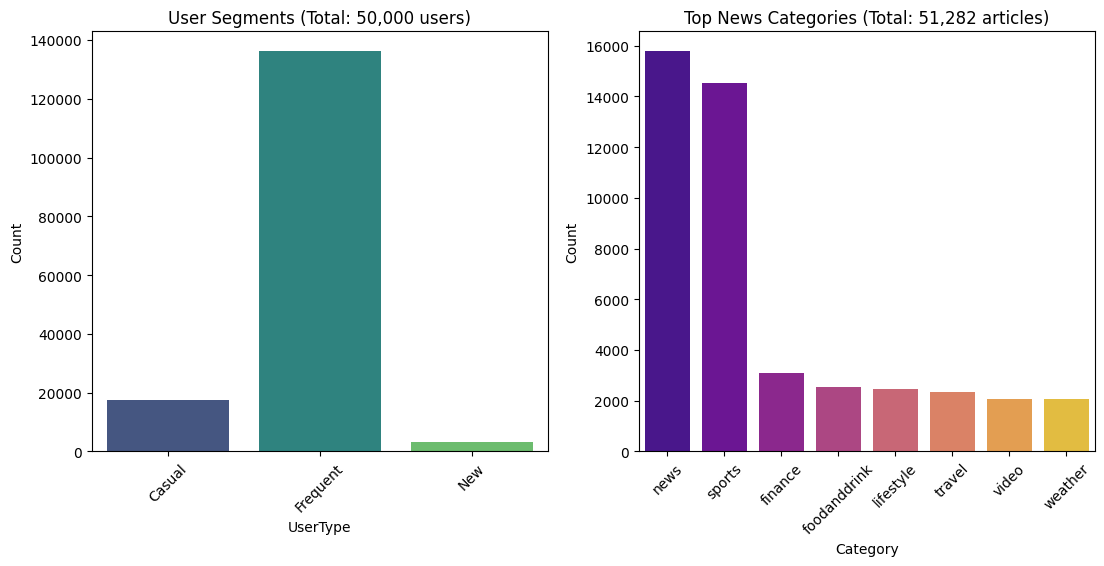

In [27]:
fig = plt.figure(figsize=(20, 12))

# 1. Users overview
plt.subplot(2, 3, 1)
user_counts = behaviors['UserType'].value_counts().sort_index()
sns.barplot(x=user_counts.index, y=user_counts.values, palette='viridis')
plt.title(f'User Segments (Total: {behaviors["UserID"].nunique():,} users)')
plt.ylabel('Count')
plt.xticks(rotation=45)

# 2. News categories
plt.subplot(2, 3, 2)
category_counts = news['Category'].value_counts().head(8)
sns.barplot(x=category_counts.index, y=category_counts.values, palette='plasma')
plt.title(f'Top News Categories (Total: {len(news):,} articles)')
plt.ylabel('Count')
plt.xticks(rotation=45)

In [28]:
print(behaviors.columns.tolist())

['ImpressionID', 'UserID', 'Time', 'History', 'Impressions', 'ImpressionList', 'Clicks', 'TotalShown', 'HistoryLength', 'Hour', 'CTR', 'UserType', 'ImpressionCount', 'DayOfWeek', 'WeekOfYear', 'DayOfMonth', 'Date', 'DayName', 'SessionDate', 'SessionID', 'HistorySequence']


# PART 2: EDA for news.tsv



1. Basic Info

Shape, null values

Unique news articles

In [29]:
print(news.shape)
print(news.isnull().sum())
print("Unique News IDs:", news['NewsID'].nunique())

(51282, 8)
NewsID                 0
Category               0
SubCategory            0
Title                  0
Abstract            2666
URL                    0
TitleEntities          3
AbstractEntities       4
dtype: int64
Unique News IDs: 51282


2. Category Distribution
   
Most common categories and subcategories

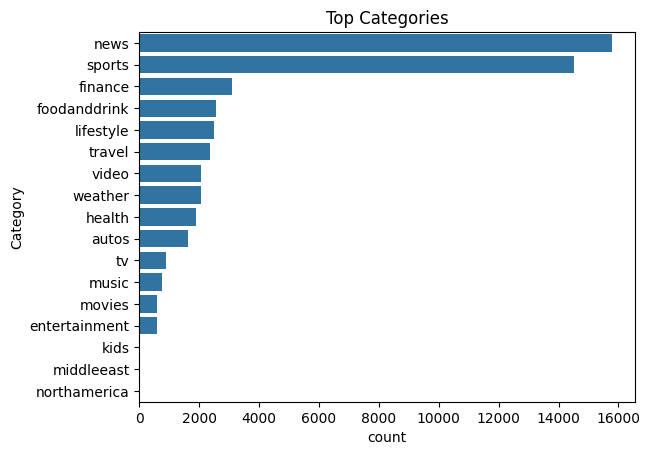

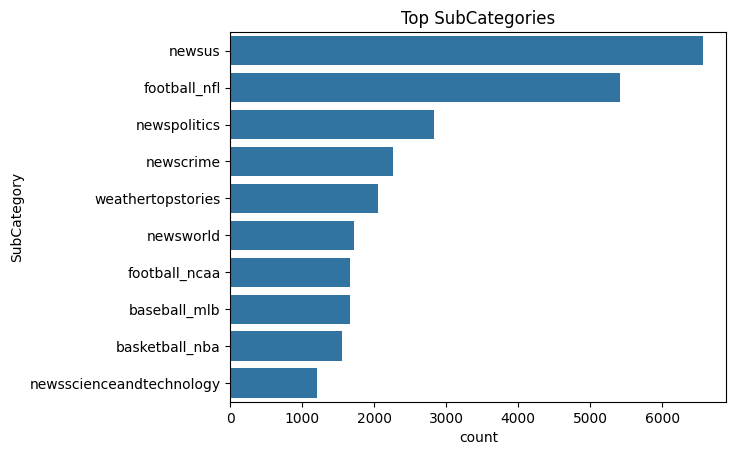

In [30]:
sns.countplot(data=news, y='Category', order=news['Category'].value_counts().index)
plt.title("Top Categories")
plt.show()

sns.countplot(data=news, y='SubCategory', order=news['SubCategory'].value_counts().index[:10])
plt.title("Top SubCategories")
plt.show()

C:\Users\rafi_\AppData\Local\Temp\ipykernel_23176\2119410121.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=category_counts.index, y=category_counts.values, palette='viridis')


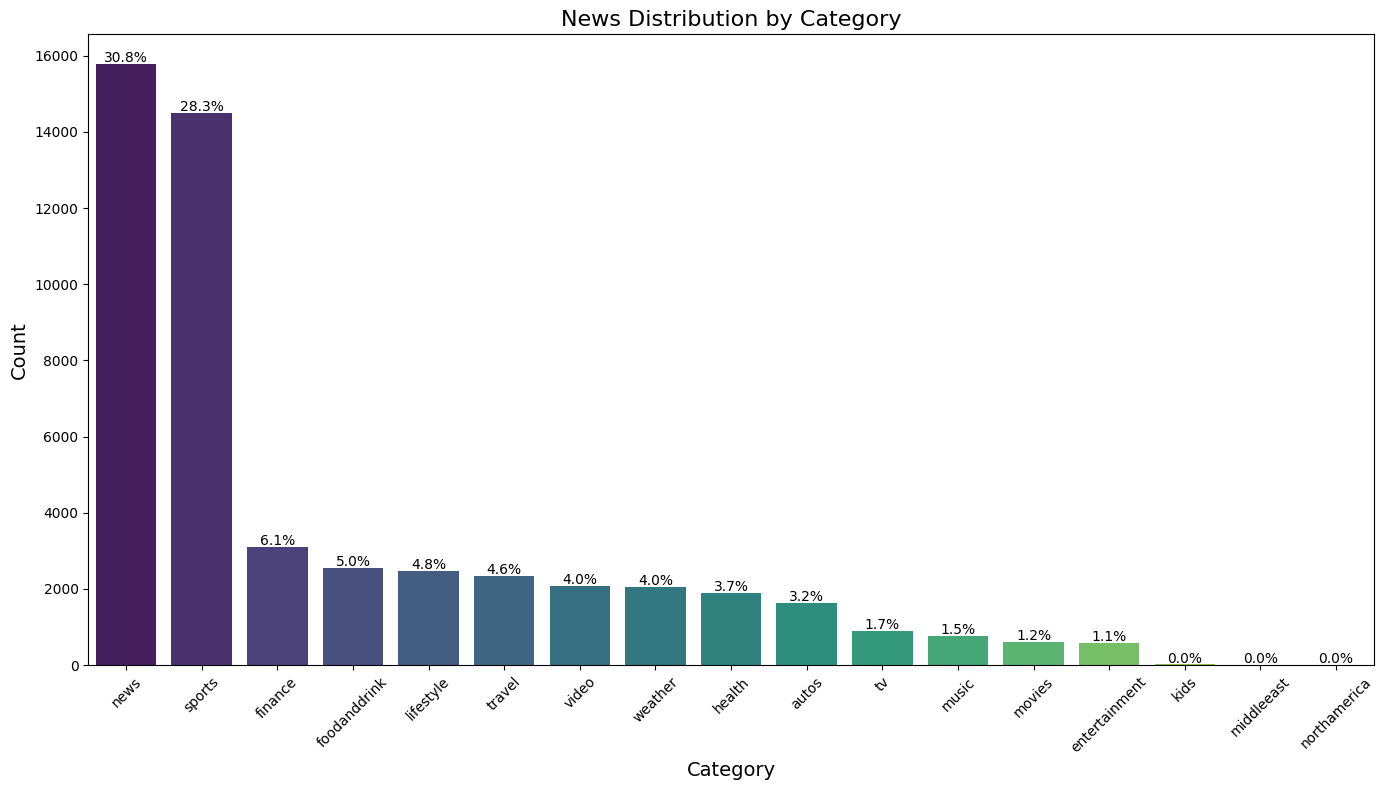

In [31]:
# Enhanced category visualization with percentage
category_counts = news['Category'].value_counts()
category_pct = category_counts / len(news) * 100

plt.figure(figsize=(14, 8))
ax = sns.barplot(x=category_counts.index, y=category_counts.values, palette='viridis')
plt.title('News Distribution by Category', fontsize=16)
plt.xlabel('Category', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(rotation=45)

# Add percentage labels
for i, (count, pct) in enumerate(zip(category_counts, category_pct)):
    ax.text(i, count + 50, f"{pct:.1f}%", ha='center', fontsize=10)

plt.tight_layout()
plt.show()


Category-subcategory relationships

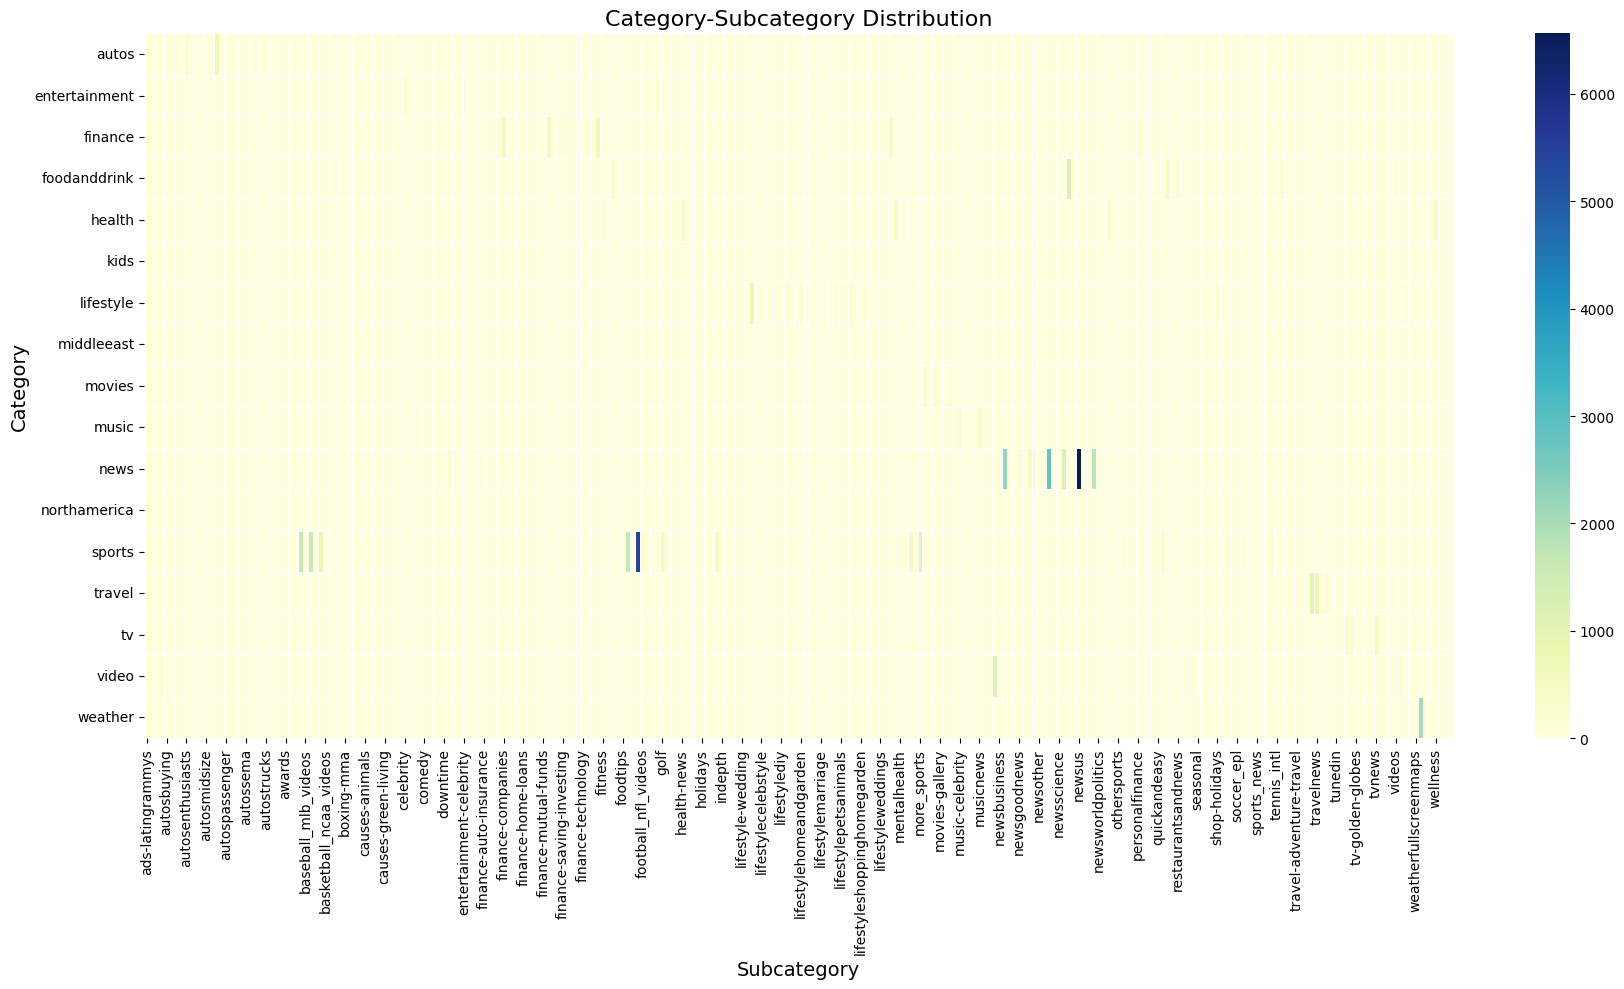

In [32]:
# Category-subcategory relationships
category_subcategory = news.groupby(['Category', 'SubCategory']).size().reset_index(name='Count')
pivot_table = category_subcategory.pivot_table(values='Count', index='Category', columns='SubCategory', fill_value=0)

plt.figure(figsize=(18, 10))
sns.heatmap(pivot_table, cmap='YlGnBu', annot=False, linewidths=0.5)
plt.title('Category-Subcategory Distribution', fontsize=16)
plt.ylabel('Category', fontsize=14)
plt.xlabel('Subcategory', fontsize=14)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

3. Title and Abstract Lengths
   
Analyze word count in title and abstract

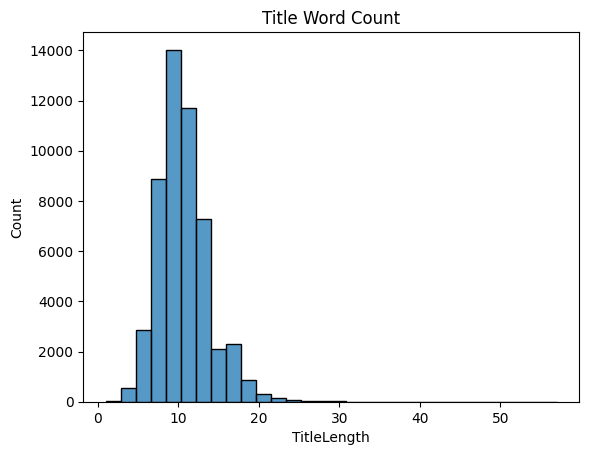

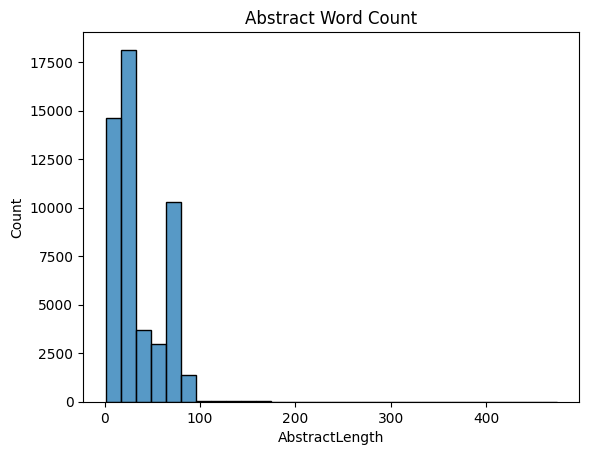

In [33]:
news['TitleLength'] = news['Title'].apply(lambda x: len(str(x).split()))
news['AbstractLength'] = news['Abstract'].apply(lambda x: len(str(x).split()))

# Plot
sns.histplot(news['TitleLength'], bins=30)
plt.title("Title Word Count")
plt.show()

sns.histplot(news['AbstractLength'], bins=30)
plt.title("Abstract Word Count")
plt.show()

4. Entity Analysis
   
Most frequently mentioned entities in titles and abstracts



In [34]:
news['TitleEntities'] = news['TitleEntities'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])
news['AbstractEntities'] = news['AbstractEntities'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])

title_entity_labels = [ent['Label'] for row in news['TitleEntities'] for ent in row]
abstract_entity_labels = [ent['Label'] for row in news['AbstractEntities'] for ent in row]

# Frequency
title_entity_freq = pd.Series(title_entity_labels).value_counts().head(10)
abstract_entity_freq = pd.Series(abstract_entity_labels).value_counts().head(10)

print("Top Title Entities:\n", title_entity_freq)
print("Top Abstract Entities:\n", abstract_entity_freq)


Top Title Entities:
 Donald Trump                        1501
National Football League             510
United States                        398
New England Patriots                 392
Houston Astros                       369
California                           339
Republican Party (United States)     289
Democratic Party (United States)     273
Florida                              265
Ukraine                              263
Name: count, dtype: int64
Top Abstract Entities:
 Donald Trump                        1821
United States                       1102
National Football League             697
California                           584
New England Patriots                 547
Democratic Party (United States)     449
Republican Party (United States)     432
Houston Astros                       412
Ukraine                              388
Florida                              382
Name: count, dtype: int64


5. Duplicate News Titles
   
Check if there are duplicate news titles (potential republished content).

In [35]:
duplicate_titles = news['Title'].duplicated().sum()
print("Number of duplicate news titles:", duplicate_titles)

Number of duplicate news titles: 848


6. Category vs. Abstract/Title Length
   
Do certain categories tend to have longer or shorter abstracts/titles?

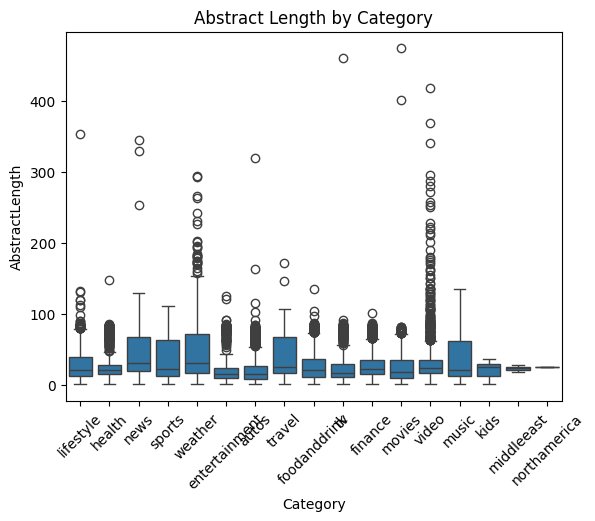

In [36]:
sns.boxplot(data=news, x='Category', y='AbstractLength')
plt.xticks(rotation=45)
plt.title("Abstract Length by Category")
plt.show()

8. TF-IDF Keyword Extraction
    
Identify top keywords in titles or abstracts using TF-IDF.

In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=20, stop_words='english')
X = vectorizer.fit_transform(news['Title'].fillna(''))
keywords = vectorizer.get_feature_names_out()

print("Top TF-IDF keywords in news titles:\n", keywords)

Top TF-IDF keywords in news titles:
 ['2019' 'best' 'day' 'football' 'game' 'home' 'impeachment' 'man' 'new'
 'old' 'police' 'report' 'says' 'school' 'state' 'trump' 'vs' 'week' 'win'
 'year']


9. Category-Entity Heatmap
   
Map how entities are distributed across different categories.

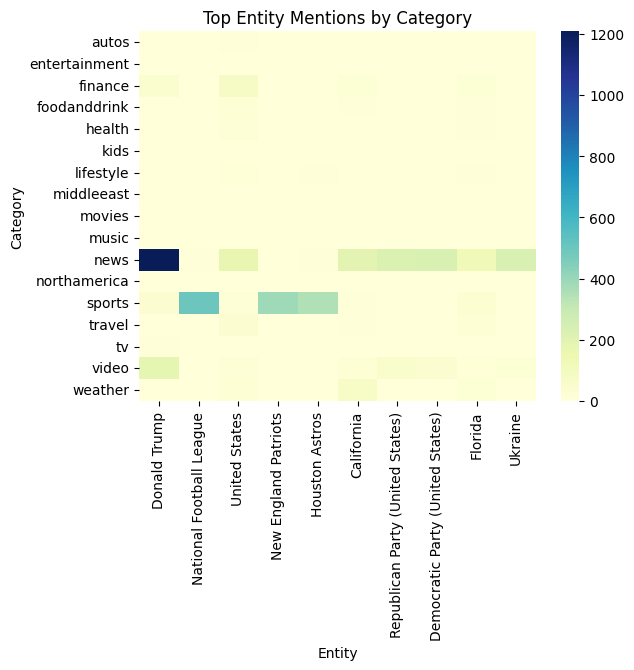

In [38]:
from collections import defaultdict

category_entity_map = defaultdict(list)

for _, row in news.iterrows():
    category = row['Category']
    for ent in row['TitleEntities']:
        category_entity_map[category].append(ent['Label'])

df = pd.DataFrame([
    (cat, ent) for cat, ents in category_entity_map.items()
    for ent in ents
])

heatmap_data = df.groupby([0, 1]).size().unstack(fill_value=0)
top_entities = heatmap_data.sum().sort_values(ascending=False).head(10).index
sns.heatmap(heatmap_data[top_entities], cmap='YlGnBu')
plt.title("Top Entity Mentions by Category")
plt.ylabel("Category")
plt.xlabel("Entity")
plt.show()


Top Keywords in each category

C:\Users\rafi_\AppData\Local\Temp\ipykernel_23176\638298325.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=terms, y=scores, palette='viridis')
C:\Users\rafi_\AppData\Local\Temp\ipykernel_23176\638298325.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=terms, y=scores, palette='viridis')
C:\Users\rafi_\AppData\Local\Temp\ipykernel_23176\638298325.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=terms, y=scores, palette='viridis')
C:\Users\rafi_\AppData\Local\Temp\ipykernel_23176\638298325.py:34: FutureWarning: 

Passing `p

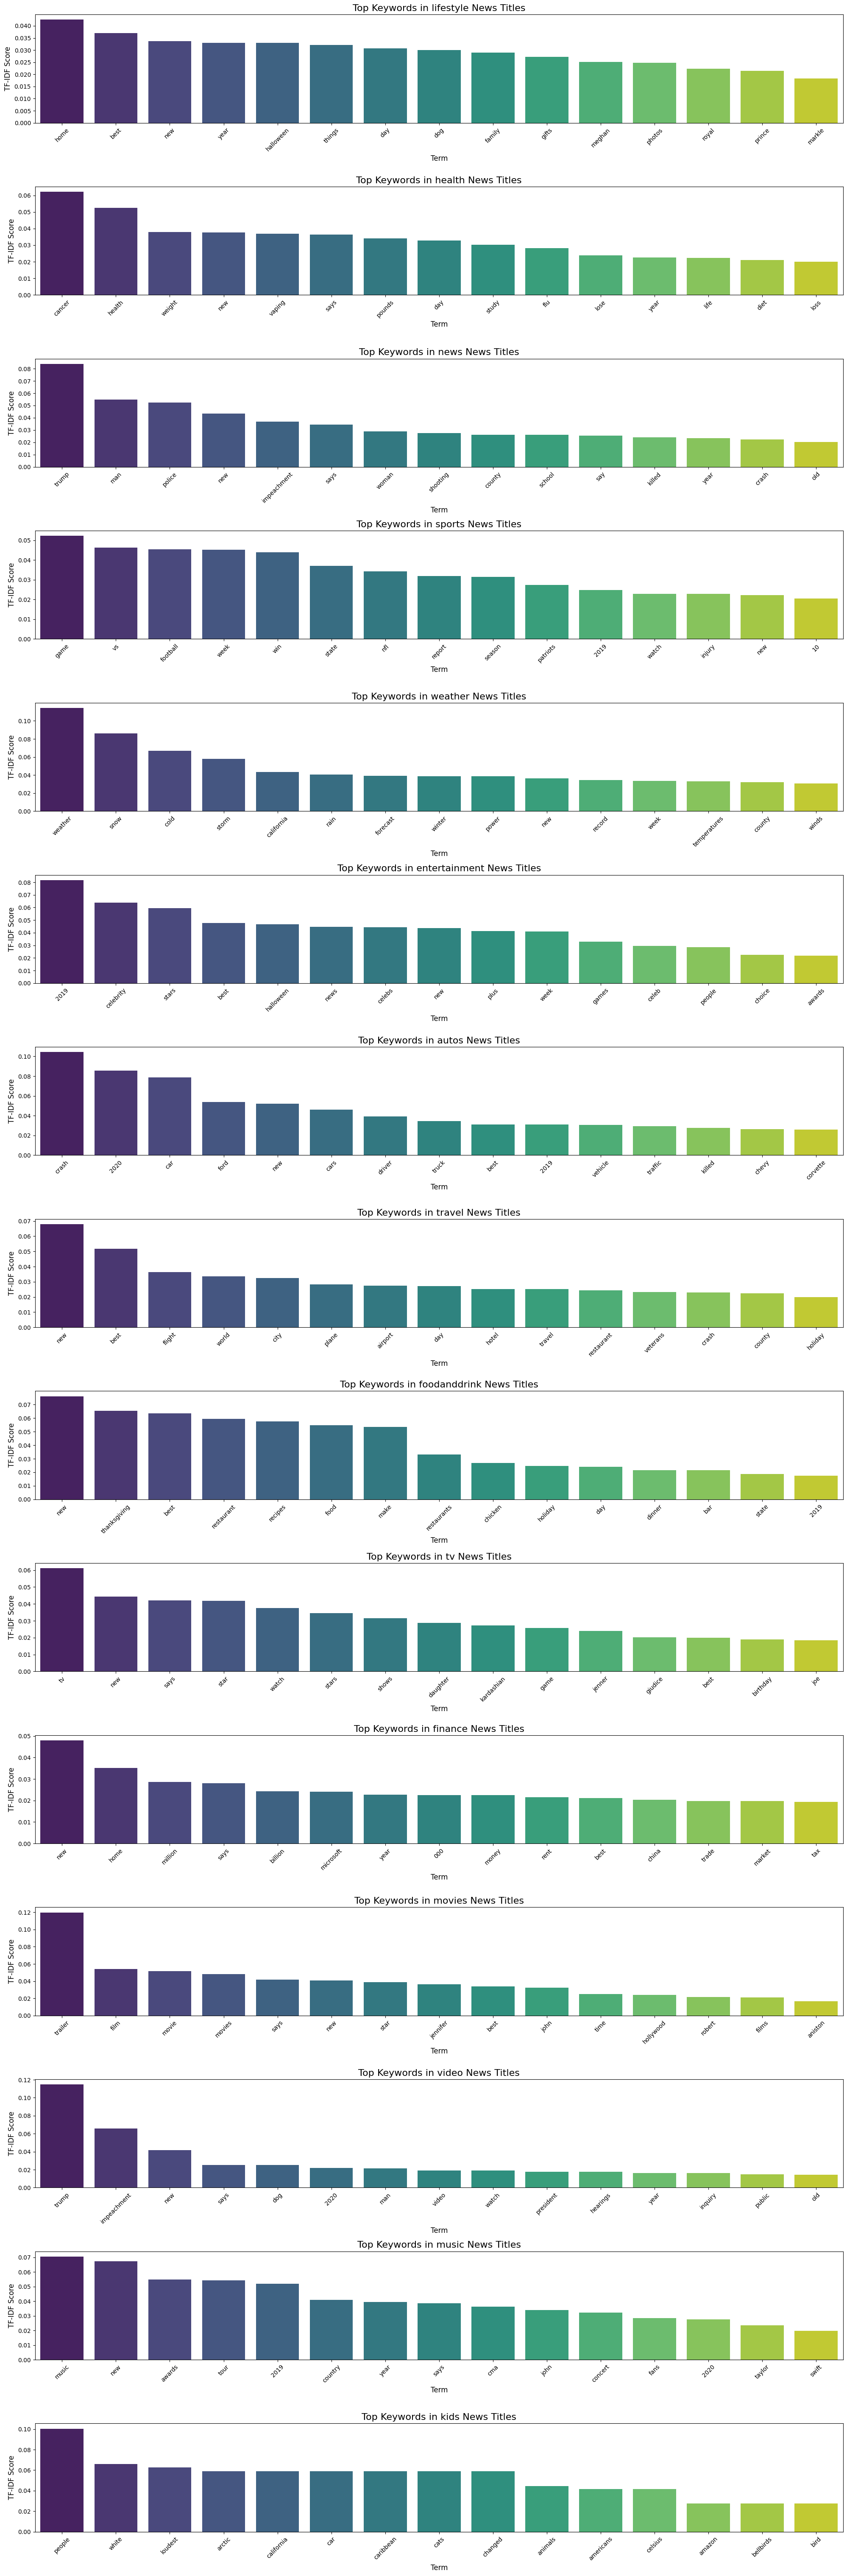

In [39]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Prepare text fields - handle missing values
news['CleanTitle'] = news['Title'].fillna('')
news['CleanAbstract'] = news['Abstract'].fillna('')

# Create a more informative TF-IDF analysis per category
categories = news['Category'].unique()

plt.figure(figsize=(20, 4 * len(categories)))
plt.subplots_adjust(hspace=0.5)

for i, category in enumerate(categories):
    category_news = news[news['Category'] == category]
    
    # Skip if too few articles
    if len(category_news) < 10:
        continue
    
    # Extract keywords from titles
    vectorizer = TfidfVectorizer(max_features=15, stop_words='english')
    tfidf_matrix = vectorizer.fit_transform(category_news['CleanTitle'])
    feature_names = vectorizer.get_feature_names_out()
    
    # Get average TF-IDF score for each term
    tfidf_means = tfidf_matrix.mean(axis=0).A1
    tfidf_scores = list(zip(feature_names, tfidf_means))
    tfidf_scores.sort(key=lambda x: x[1], reverse=True)
    
    # Plot
    plt.subplot(len(categories), 1, i+1)
    terms = [term for term, score in tfidf_scores]
    scores = [score for term, score in tfidf_scores]
    sns.barplot(x=terms, y=scores, palette='viridis')
    plt.title(f'Top Keywords in {category} News Titles', fontsize=16)
    plt.xlabel('Term', fontsize=12)
    plt.ylabel('TF-IDF Score', fontsize=12)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [40]:
from sklearn.decomposition import NMF

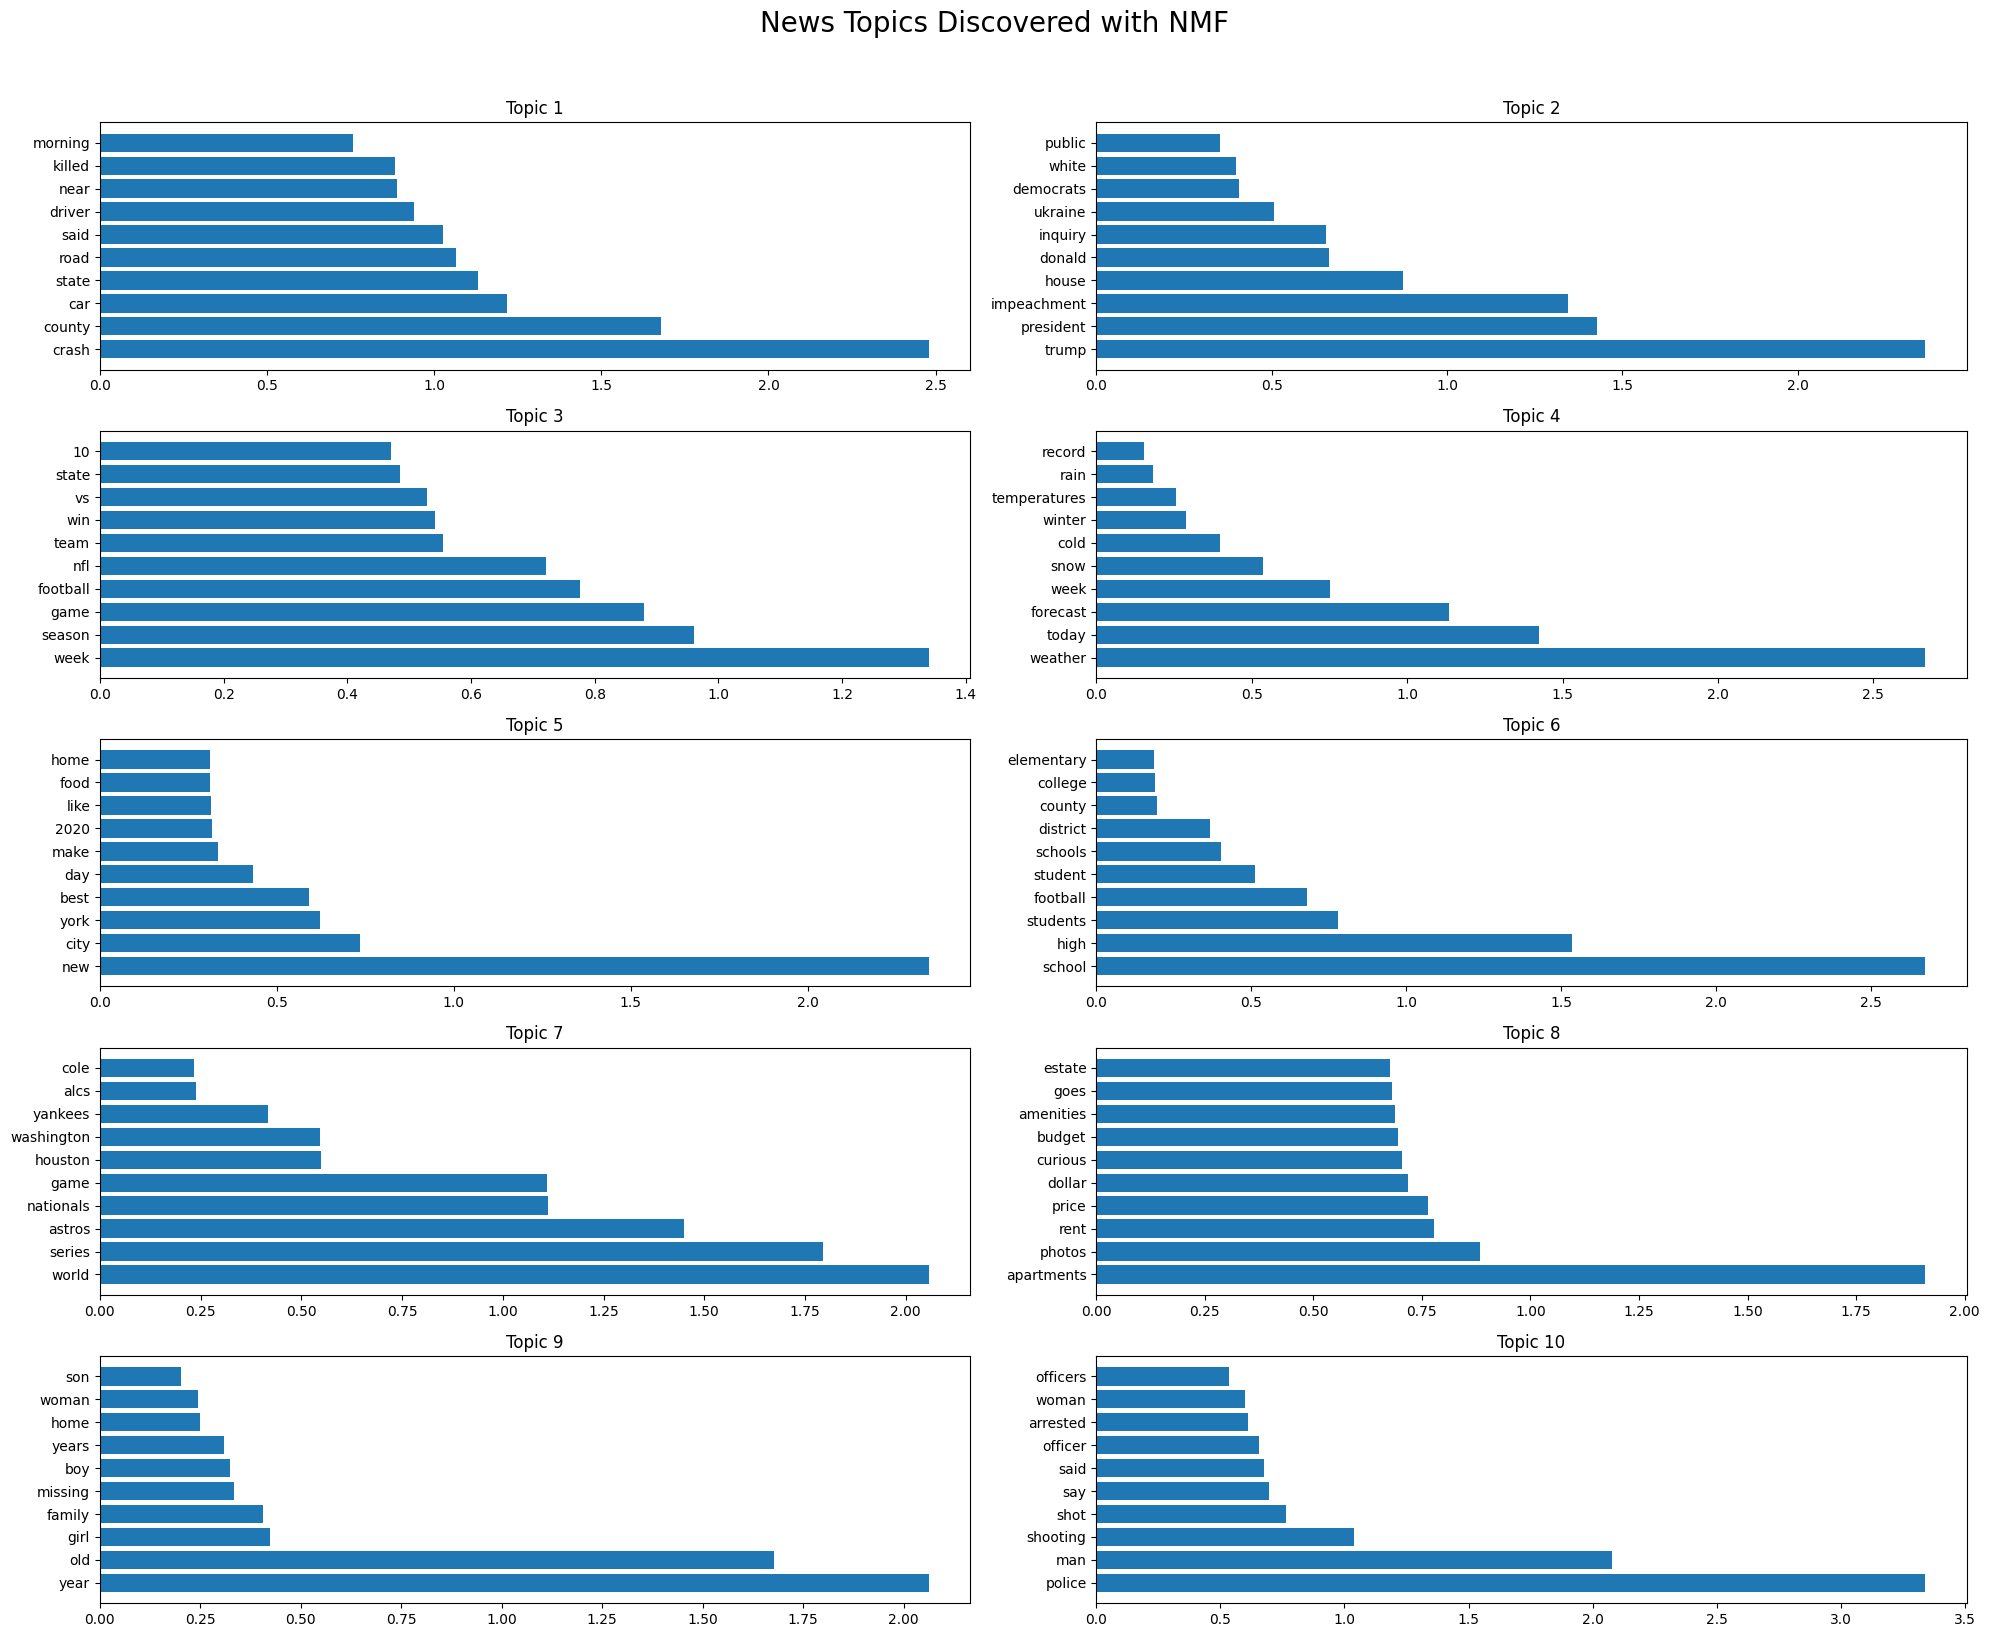

In [41]:
news['CombinedText'] = news['CleanTitle'] + ' ' + news['CleanAbstract']

# Vectorize text
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
tfidf_matrix = vectorizer.fit_transform(news['CombinedText'])
feature_names = vectorizer.get_feature_names_out()

# Apply NMF
n_topics = 10
nmf_model = NMF(n_components=n_topics, random_state=42)
nmf_features = nmf_model.fit_transform(tfidf_matrix)

# Topic keywords
topic_keywords = []
for topic_idx, topic in enumerate(nmf_model.components_):
    top_keywords_idx = topic.argsort()[:-11:-1]  # Get top 10 keywords
    top_keywords = [feature_names[i] for i in top_keywords_idx]
    topic_keywords.append(top_keywords)

# Visualize topics
plt.figure(figsize=(20, 16))
for i, keywords in enumerate(topic_keywords):
    plt.subplot(5, 2, i+1)
    y_pos = np.arange(len(keywords))
    topic_importance = nmf_model.components_[i, np.argsort(-nmf_model.components_[i])[:10]]
    plt.barh(y_pos, topic_importance)
    plt.yticks(y_pos, keywords)
    plt.title(f'Topic {i+1}')
    plt.tight_layout()

plt.suptitle('News Topics Discovered with NMF', fontsize=20, y=1.02)
plt.tight_layout()
plt.show()


CTR by news category

C:\Users\rafi_\AppData\Local\Temp\ipykernel_23176\1044825658.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_ctr.index, y=category_ctr['CTR'], palette='viridis')


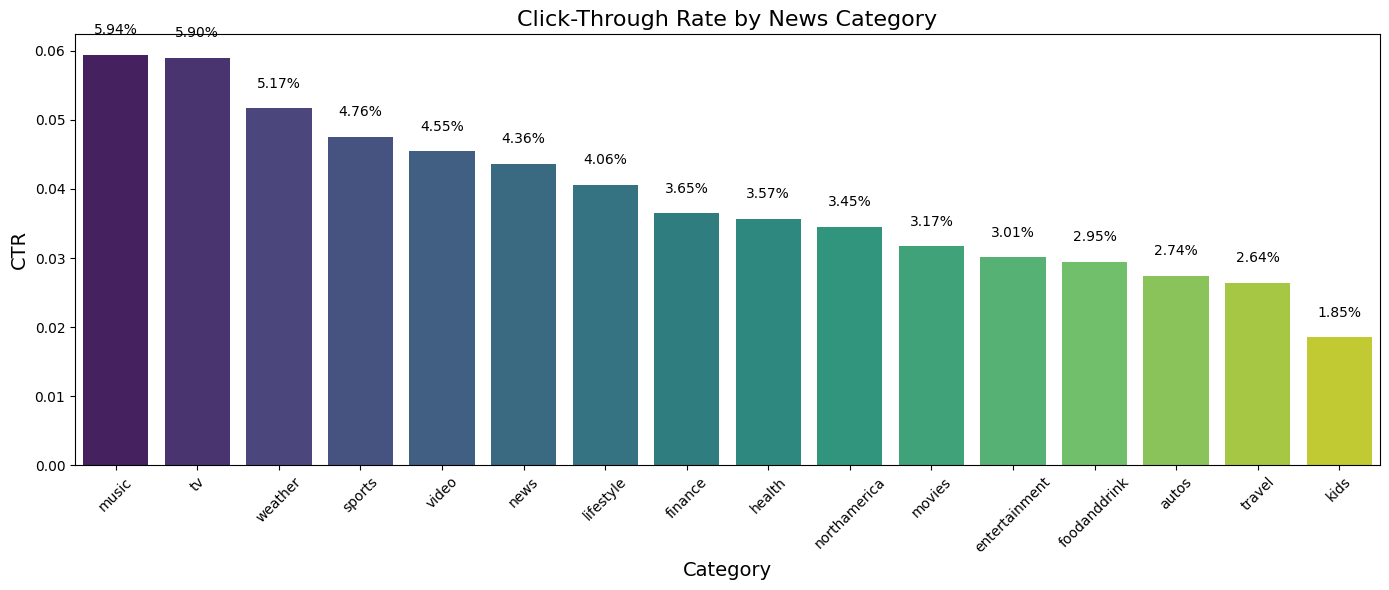

In [42]:
news_features = news.set_index('NewsID')

# Extract all impression records
all_impressions = []
for idx, row in behaviors.iterrows():
    for news_id, clicked in row['ImpressionList']:
        all_impressions.append({
            'UserID': row['UserID'],
            'NewsID': news_id,
            'Clicked': int(clicked),
            'UserType': row['UserType'],
            'Hour': row['Hour'],
            'DayOfWeek': row['DayOfWeek']
        })

impressions_df = pd.DataFrame(all_impressions)

# Merge with news features
merged_df = impressions_df.join(news_features, on='NewsID', how='left')

# Calculate CTR by category
category_ctr = merged_df.groupby('Category')['Clicked'].agg(['count', 'sum', 'mean'])
category_ctr.columns = ['Impressions', 'Clicks', 'CTR']
category_ctr = category_ctr.sort_values('CTR', ascending=False)

plt.figure(figsize=(14, 6))
sns.barplot(x=category_ctr.index, y=category_ctr['CTR'], palette='viridis')
plt.title('Click-Through Rate by News Category', fontsize=16)
plt.xlabel('Category', fontsize=14)
plt.ylabel('CTR', fontsize=14)
plt.xticks(rotation=45)

# Add percentage labels
for i, ctr in enumerate(category_ctr['CTR']):
    plt.text(i, ctr + 0.003, f"{ctr*100:.2f}%", ha='center')

plt.tight_layout()
plt.show()


User-Content Affinity Analysis

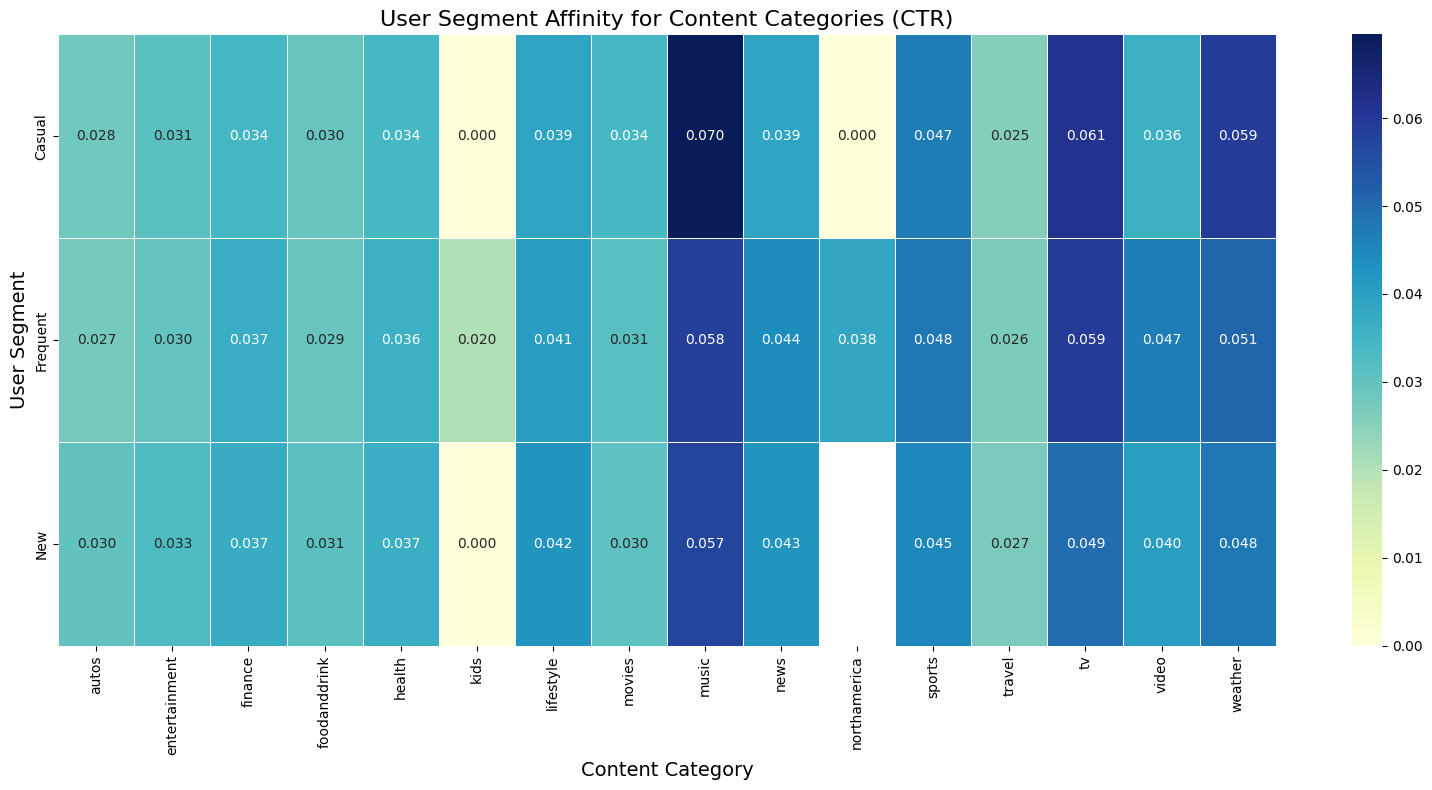

In [43]:
# Do certain user segments have preferences for particular content?

user_category_ctr = merged_df.groupby(['UserType', 'Category'])['Clicked'].agg(['count', 'sum', 'mean'])
user_category_ctr.columns = ['Impressions', 'Clicks', 'CTR']
user_category_pivot = user_category_ctr.reset_index().pivot(index='UserType', columns='Category', values='CTR')

plt.figure(figsize=(16, 8))
sns.heatmap(user_category_pivot, cmap='YlGnBu', annot=True, fmt='.3f', linewidths=0.5)
plt.title('User Segment Affinity for Content Categories (CTR)', fontsize=16)
plt.ylabel('User Segment', fontsize=14)
plt.xlabel('Content Category', fontsize=14)
plt.tight_layout()
plt.show()

Temporal Patterns in Content Consumption

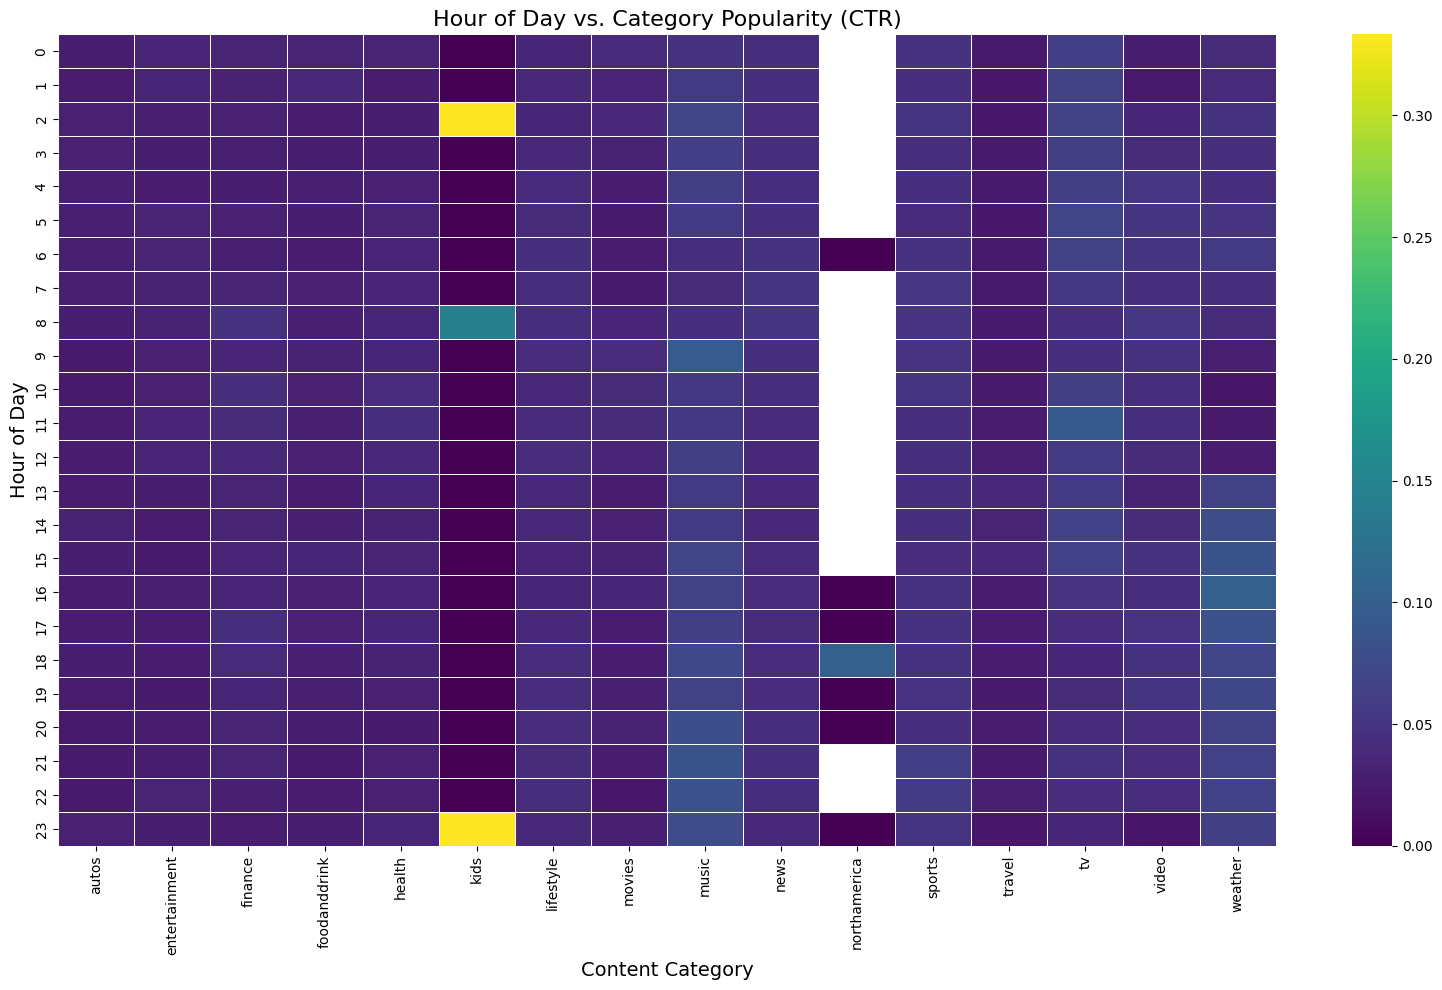

In [44]:
# Are certain categories more popular at different times?

hour_category_ctr = merged_df.groupby(['Hour', 'Category'])['Clicked'].agg(['count', 'sum', 'mean'])
hour_category_ctr.columns = ['Impressions', 'Clicks', 'CTR']
hour_category_pivot = hour_category_ctr.reset_index().pivot(index='Hour', columns='Category', values='CTR')

plt.figure(figsize=(16, 10))
sns.heatmap(hour_category_pivot, cmap='viridis', annot=False, linewidths=0.5)
plt.title('Hour of Day vs. Category Popularity (CTR)', fontsize=16)
plt.ylabel('Hour of Day', fontsize=14)
plt.xlabel('Content Category', fontsize=14)
plt.tight_layout()
plt.show()


CTR by User Experience Level

C:\Users\rafi_\AppData\Local\Temp\ipykernel_23176\2233167623.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=cold_start_metrics.index, y=cold_start_metrics['CTR'], palette='viridis')


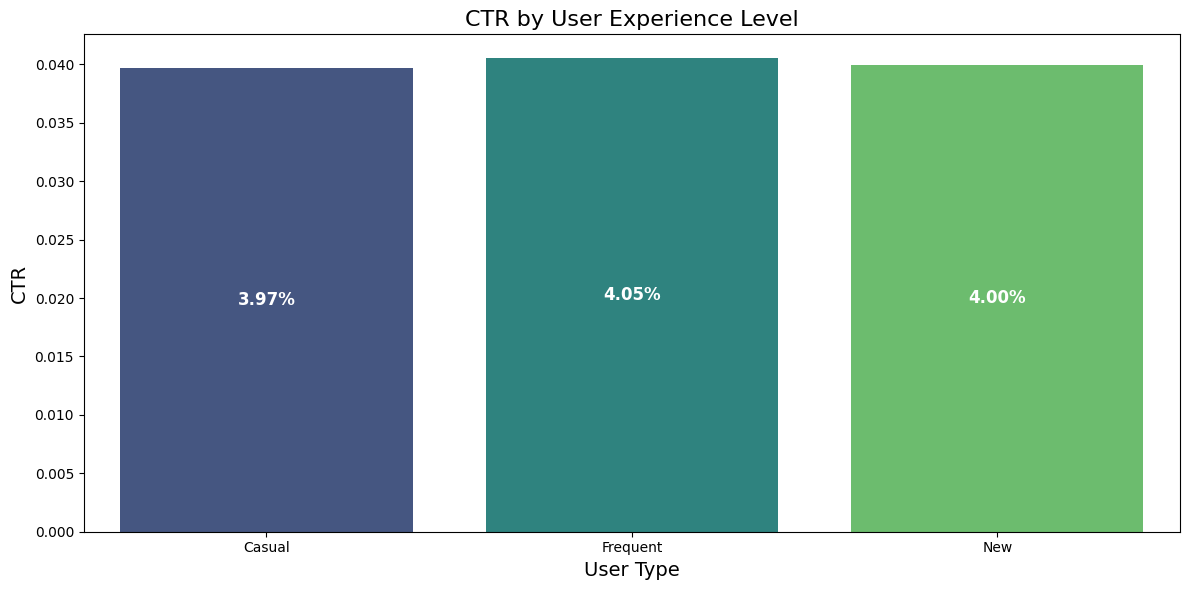

In [45]:
# Recalculate cold_start_metrics
cold_start_metrics = merged_df.groupby('UserType')['Clicked'].agg(['count', 'sum', 'mean'])
cold_start_metrics.columns = ['Impressions', 'Clicks', 'CTR']
cold_start_metrics['Percentage of Impressions'] = cold_start_metrics['Impressions'] / cold_start_metrics['Impressions'].sum() * 100

# Plot
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=cold_start_metrics.index, y=cold_start_metrics['CTR'], palette='viridis')
plt.title('CTR by User Experience Level', fontsize=16)
plt.xlabel('User Type', fontsize=14)
plt.ylabel('CTR', fontsize=14)

# Add percentage labels inside the bars
for i, ctr in enumerate(cold_start_metrics['CTR']):
    plt.text(i, ctr / 2, f"{ctr*100:.2f}%", ha='center', va='center', color='white', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()
